# Cluster Analysis

This notebook loads and analyzes cluster data from DBSCAN clustering runs with varying hyperparameters.

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import glob
import sys
#from pymanticore.analysis.matplotlib import get_mplstyle_path

sys.path.insert(0, os.path.abspath('..'))

from backend.io import load_clusters_from_hdf5

mnras_style = "mnras"

## Configuration

Set the directory path containing the cluster HDF5 files.

In [2]:
CLUSTER_DIR = "../output"

print(f"Looking for cluster files in: {os.path.abspath(CLUSTER_DIR)}")

Looking for cluster files in: /home/stuart-mcalpine/Desktop/Manticore/gits/manticore_posterior_clusters/output


## Filename Parsing

Parse cluster filenames to extract `eps` and `min_samples` values. Expected format: `clusters_eps_{eps}_min_samples_{min_samples}.h5` where eps uses 'p' instead of decimal point (e.g., `2p5` for 2.5).

In [22]:
def parse_cluster_filename(filename):
    """
    Parse cluster filename to extract eps and min_samples values.
    
    Parameters
    ----------
    filename : str
        Filename (not full path) to parse
    
    Returns
    -------
    tuple
        (eps, min_samples) or (None, None) if parsing fails
    """
    pattern = r'clusters_eps_([0-9]+p?[0-9]*)_min_samples_(\d+)\.h5'
    match = re.match(pattern, filename)
    
    if match:
        eps_str = match.group(1)
        min_samples_str = match.group(2)
        
        eps = float(eps_str.replace('p', '.'))
        min_samples = int(min_samples_str)
        
        return eps, min_samples
    
    return None, None

## Discover Cluster Files

Find all cluster HDF5 files in the specified directory and extract their parameter values.

In [4]:
cluster_files = glob.glob(os.path.join(CLUSTER_DIR, 'clusters_eps_*_min_samples_*.h5'))

eps_values = set()
min_samples_values = set()
param_to_filepath = {}

for filepath in cluster_files:
    filename = os.path.basename(filepath)
    eps, min_samples = parse_cluster_filename(filename)
    
    if eps is not None and min_samples is not None:
        eps_values.add(eps)
        min_samples_values.add(min_samples)
        param_to_filepath[(eps, min_samples)] = filepath

eps_values = sorted(list(eps_values))
min_samples_values = sorted(list(min_samples_values))

print(f"Discovered {len(cluster_files)} cluster files")
print(f"Eps values: {eps_values}")
print(f"Min_samples values: {min_samples_values}")
print(f"Parameter combinations found: {len(param_to_filepath)}")

Discovered 230 cluster files
Eps values: [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0]
Min_samples values: [3, 5, 7, 9, 11]
Parameter combinations found: 230


## Load Cluster Data

Load cluster data from each discovered file and store in a dictionary keyed by `(eps, min_samples)`.

In [5]:
cluster_data = {}

for (eps, min_samples), filepath in sorted(param_to_filepath.items()):
    filename = os.path.basename(filepath)
    
    try:
        clusters, metadata = load_clusters_from_hdf5(CLUSTER_DIR, filename=filename, minimal=False)
        
        cluster_data[(eps, min_samples)] = {
            'clusters': clusters,
            'metadata': metadata,
            'n_clusters': len(clusters),
            'filepath': filepath
        }
        
        print(f"eps={eps}, min_samples={min_samples}: loaded {len(clusters)} clusters")
        
    except Exception as e:
        print(f"eps={eps}, min_samples={min_samples}: ERROR - {e}")

print(f"\nSuccessfully loaded {len(cluster_data)} parameter combinations")

eps=0.5, min_samples=3: loaded 60 clusters
eps=0.5, min_samples=5: loaded 39 clusters
eps=0.5, min_samples=7: loaded 24 clusters
eps=0.5, min_samples=9: loaded 14 clusters
eps=0.5, min_samples=11: loaded 11 clusters
eps=0.6, min_samples=3: loaded 105 clusters
eps=0.6, min_samples=5: loaded 77 clusters
eps=0.6, min_samples=7: loaded 56 clusters
eps=0.6, min_samples=9: loaded 33 clusters
eps=0.6, min_samples=11: loaded 24 clusters
eps=0.7, min_samples=3: loaded 187 clusters
eps=0.7, min_samples=5: loaded 125 clusters
eps=0.7, min_samples=7: loaded 90 clusters
eps=0.7, min_samples=9: loaded 62 clusters
eps=0.7, min_samples=11: loaded 48 clusters
eps=0.8, min_samples=3: loaded 247 clusters
eps=0.8, min_samples=5: loaded 190 clusters
eps=0.8, min_samples=7: loaded 131 clusters
eps=0.8, min_samples=9: loaded 92 clusters
eps=0.8, min_samples=11: loaded 72 clusters
eps=0.9, min_samples=3: loaded 293 clusters
eps=0.9, min_samples=5: loaded 247 clusters
eps=0.9, min_samples=7: loaded 198 cluster

eps=1.25, min_samples=5: loaded 172 clusters


eps=1.25, min_samples=7: loaded 139 clusters


eps=1.25, min_samples=9: loaded 120 clusters


eps=1.35, min_samples=3: loaded 215 clusters


...

eps=2.75, min_samples=9: loaded 376 clusters


eps=3.0, min_samples=3: loaded 388 clusters


eps=3.0, min_samples=5: loaded 396 clusters


eps=3.0, min_samples=7: loaded 411 clusters


eps=3.0, min_samples=9: loaded 403 clusters

Successfully loaded 64 parameter combinations


In [30]:
def find_matching_association(clusters, target_position, max_distance=10):
    """Find the association closest to the target position (position-based matching)."""
    best_match = None
    best_dist = float('inf')
    
    for cluster in clusters:
        pos = np.array(cluster['mean_position'])
        dist = np.linalg.norm(pos - np.array(target_position))
        
        if dist < best_dist and dist < max_distance:
            best_dist = dist
            best_match = cluster
    
    return best_match, best_dist


def find_matching_association_by_members(clusters, reference_halo_ids):
    """
    Find the association that contains the most members from the reference set (member-based matching).
    
    Parameters
    ----------
    clusters : list
        List of cluster dictionaries to search
    reference_halo_ids : set
        Set of (mcmc_id, halo_original_index) tuples from the reference association
    
    Returns
    -------
    tuple
        (best_match_cluster, n_shared_members, fraction_shared)
        - best_match_cluster: The cluster with the most overlapping members, or None if no overlap
        - n_shared_members: Number of members shared with the reference
        - fraction_shared: Fraction of reference members found in the match (n_shared / len(reference))
    """
    if len(reference_halo_ids) == 0:
        return None, 0, 0.0
    
    best_match = None
    best_n_shared = 0
    best_mass = 0
    
    for cluster in clusters:
        cluster_halo_ids = get_unique_halo_ids(cluster)
        
        # Count how many reference members are in this cluster
        n_shared = len(reference_halo_ids & cluster_halo_ids)
        
        if n_shared > 0:
            cluster_mass = cluster.get('mean_m200_mass', 0)
            
            # Update best match if:
            # 1. More shared members, OR
            # 2. Same shared members but larger mass (tie-breaker)
            if n_shared > best_n_shared or (n_shared == best_n_shared and cluster_mass > best_mass):
                best_match = cluster
                best_n_shared = n_shared
                best_mass = cluster_mass
    
    fraction_shared = best_n_shared / len(reference_halo_ids) if best_match else 0.0
    
    return best_match, best_n_shared, fraction_shared


def compute_sigma_r(cluster):
    """Compute 3D positional scatter from member positions."""
    member_data = cluster.get('member_data', {})
    positions = member_data.get('SO/200/crit/CentreOfMass', None)
    
    if positions is not None and len(positions) > 1:
        std_x = np.std(positions[:, 0])
        std_y = np.std(positions[:, 1])
        std_z = np.std(positions[:, 2])
        return np.sqrt(std_x**2 + std_y**2 + std_z**2)
    return np.nan


def get_unique_halo_ids(cluster):
    """
    Extract unique halo IDs from a cluster by combining mcmc_id and halo_original_index.
    
    Returns a set of (mcmc_id, halo_original_index) tuples.
    """
    member_data = cluster.get('member_data', {})
    mcmc_ids = member_data.get('mcmc/id', None)
    halo_indices = member_data.get('halo/original/index', None)
    
    if mcmc_ids is None or halo_indices is None:
        return set()
    
    return set(zip(mcmc_ids.astype(int), halo_indices.astype(int)))


def detect_merger_point(eps_arr, frac_shared, drop_threshold=0.2, min_recovery_after=0.7):
    """
    Detect merger point by finding where recovery drops sharply.
    
    A merger is detected when:
    1. Recovery drops by more than drop_threshold (e.g., 20%) from one eps to the next, OR
    2. Recovery drops from above min_recovery_after to below it
    
    Parameters
    ----------
    eps_arr : array
        Array of eps values (sorted, ascending)
    frac_shared : array
        Array of recovery fractions corresponding to eps values
    drop_threshold : float
        Minimum drop in recovery fraction to count as a cliff (default: 0.2 = 20%)
    min_recovery_after : float
        If recovery was above this and drops below, it's a merger (default: 0.7 = 70%)
    
    Returns
    -------
    int
        Index of the merger point (first point after the cliff), or len(eps_arr) if no merger
    float
        eps value at merger point
    str
        Detection method used ('drop', 'threshold', or 'none')
    """
    n = len(eps_arr)
    
    if n < 2:
        return n, eps_arr[-1] if n > 0 else 0.0, 'none'
    
    # Method 1: Look for sharp drops (cliff detection)
    for i in range(n - 1):
        drop = frac_shared[i] - frac_shared[i + 1]
        
        # Sharp drop detected
        if drop >= drop_threshold:
            return i + 1, eps_arr[i + 1], 'drop'
        
        # Crossing from high recovery to low
        if frac_shared[i] >= min_recovery_after and frac_shared[i + 1] < min_recovery_after:
            return i + 1, eps_arr[i + 1], 'threshold'
    
    # No merger detected
    return n, eps_arr[-1] + 0.1, 'none'


def compute_stability_score(tracked_associations, reference_eps, n_reference_members,
                            drop_threshold=0.2, min_recovery_after=0.7, mass_cv_scale=2.0):
    """
    Compute stability score for an association based on UPWARD tracking from fiducial eps.
    
    The stability score measures:
    1. Distance to merger point (detected by sharp drop in recovery)
    2. Mass consistency in the pre-merger plateau
    3. Mean recovery in the pre-merger plateau
    
    Parameters
    ----------
    tracked_associations : dict
        Dictionary mapping eps -> tracking info dict with keys:
        'frac_shared', 'n_members', 'mass', 'sigma_r'
    reference_eps : float
        The fiducial eps value
    n_reference_members : int
        Number of unique members in the reference association
    drop_threshold : float
        Minimum drop in recovery to detect merger cliff (default: 0.2 = 20%)
    min_recovery_after : float
        Recovery threshold for merger detection (default: 0.7 = 70%)
    mass_cv_scale : float
        Scale factor for mass CV -> stability conversion (default: 2.0)
    
    Returns
    -------
    float
        Combined stability score between 0 and 1
    dict
        Component scores and diagnostics
    """
    # Filter to eps >= reference_eps (upward tracking only)
    eps_upward = sorted([e for e in tracked_associations.keys() if e >= reference_eps])
    
    if len(eps_upward) < 2:
        return 0.0, {'error': 'insufficient_upward_data', 'n_eps_upward': len(eps_upward)}
    
    eps_arr = np.array(eps_upward)
    frac_shared = np.array([tracked_associations[e]['frac_shared'] for e in eps_upward])
    masses = np.array([tracked_associations[e]['mass'] for e in eps_upward])
    
    # Detect merger point using cliff detection
    merger_idx, eps_merger, detection_method = detect_merger_point(
        eps_arr, frac_shared, drop_threshold, min_recovery_after
    )
    
    # Plateau = region from fiducial to just before merger
    plateau_mask = np.arange(len(eps_arr)) < merger_idx
    
    if plateau_mask.sum() < 1:
        # Immediate merger at fiducial - very unstable
        return 0.0, {
            'error': 'immediate_merger',
            'eps_merger': eps_merger,
            'merger_distance': 0.0,
            'detection_method': detection_method
        }
    
    # Merger distance: how far above fiducial before merging
    merger_distance = eps_merger - reference_eps
    
    # Normalize merger distance to 0-1 score
    # Use sigmoid-like scaling: distance of 1.0 Mpc gives ~0.63, 2.0 Mpc gives ~0.86
    S_merger_distance = 1.0 - np.exp(-merger_distance / 1.0)
    
    # Mass consistency in plateau (before merger)
    plateau_masses = masses[plateau_mask]
    if len(plateau_masses) >= 2:
        mass_mean = np.mean(plateau_masses)
        mass_std = np.std(plateau_masses)
        mass_cv = mass_std / mass_mean if mass_mean > 0 else 1.0
        S_mass_consistency = 1.0 / (1.0 + mass_cv_scale * mass_cv)
    else:
        mass_cv = 0.0
        S_mass_consistency = 1.0  # Single point, assume consistent
    
    # Mean recovery in plateau
    plateau_recovery = frac_shared[plateau_mask]
    S_mean_recovery = np.mean(plateau_recovery)
    
    # Combined score: geometric mean
    S_total = (S_merger_distance * S_mass_consistency * S_mean_recovery) ** (1/3)
    
    components = {
        'S_merger_distance': S_merger_distance,
        'S_mass_consistency': S_mass_consistency,
        'S_mean_recovery': S_mean_recovery,
        'merger_distance': merger_distance,
        'eps_merger': eps_merger,
        'mass_cv': mass_cv,
        'n_eps_plateau': int(plateau_mask.sum()),
        'n_eps_upward': len(eps_upward),
        'detection_method': detection_method,
        'drop_threshold': drop_threshold,
        'min_recovery_threshold': min_recovery_after
    }
    
    return S_total, components


def compute_stability_for_association(reference_cluster, cluster_data, reference_eps, 
                                       min_samples_to_track, drop_threshold=0.2,
                                       min_recovery_after=0.7, mass_cv_scale=2.0):
    """
    Compute stability score for a single association by tracking it across eps values.
    
    This is a convenience function that combines member-based tracking with stability
    score computation. Only tracks UPWARD from reference_eps.
    
    Parameters
    ----------
    reference_cluster : dict
        The reference cluster dictionary from the fiducial parameters
    cluster_data : dict
        Full cluster data dictionary keyed by (eps, min_samples)
    reference_eps : float
        The fiducial eps value
    min_samples_to_track : int
        The min_samples value to use for tracking
    drop_threshold : float
        Minimum drop in recovery to detect merger (default: 0.2)
    min_recovery_after : float
        Recovery threshold for merger detection (default: 0.7)
    mass_cv_scale : float
        Scale factor for mass CV -> stability
    
    Returns
    -------
    float
        Stability score between 0 and 1
    dict
        Component scores
    dict
        Full tracking results (eps -> tracking info)
    """
    reference_halo_ids = get_unique_halo_ids(reference_cluster)
    n_reference = len(reference_halo_ids)
    
    if n_reference == 0:
        return 0.0, {'error': 'no_members'}, {}
    
    # Get eps values for tracking (upward from reference)
    eps_for_tracking = sorted([e for e, m in cluster_data.keys() 
                               if m == min_samples_to_track and e >= reference_eps])
    
    if len(eps_for_tracking) < 2:
        return 0.0, {'error': 'insufficient_eps_values'}, {}
    
    # Track across eps values using member-based matching
    tracked = {}
    for eps in eps_for_tracking:
        params = (eps, min_samples_to_track)
        if params not in cluster_data:
            continue
            
        clusters = cluster_data[params]['clusters']
        match, n_shared, frac_shared = find_matching_association_by_members(clusters, reference_halo_ids)
        
        if match:
            tracked[eps] = {
                'cluster': match,
                'n_shared': n_shared,
                'frac_shared': frac_shared,
                'n_members': len(get_unique_halo_ids(match)),
                'mass': match.get('mean_m200_mass', 0),
                'sigma_r': compute_sigma_r(match)
            }
    
    if len(tracked) < 2:
        return 0.0, {'error': 'insufficient_tracking'}, tracked
    
    # Compute stability score
    score, components = compute_stability_score(
        tracked, reference_eps, n_reference,
        drop_threshold=drop_threshold, min_recovery_after=min_recovery_after,
        mass_cv_scale=mass_cv_scale
    )
    
    return score, components, tracked

---
# Plotting Section 1: Summary Statistics

Visualize the number of posterior associations as a function of `eps` and `min_samples`.

## Number of Associations vs Parameters

Plot showing how the number of detected associations varies with DBSCAN hyperparameters.

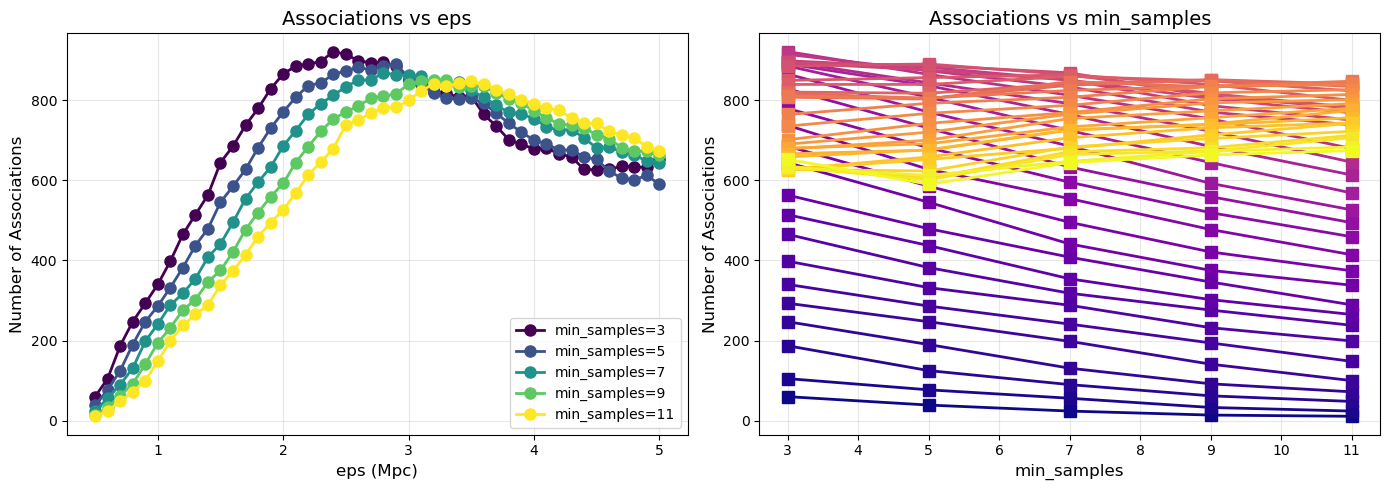

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: N_clusters vs eps, colored by min_samples
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(min_samples_values)))

for i, min_samp in enumerate(min_samples_values):
    eps_for_min = []
    n_clusters_for_min = []
    
    for eps in eps_values:
        if (eps, min_samp) in cluster_data:
            eps_for_min.append(eps)
            n_clusters_for_min.append(cluster_data[(eps, min_samp)]['n_clusters'])
    
    if len(eps_for_min) > 0:
        ax1.plot(eps_for_min, n_clusters_for_min, 'o-', color=colors[i], 
                 label=f'min_samples={min_samp}', markersize=8, linewidth=2)

ax1.set_xlabel('eps (Mpc)', fontsize=12)
ax1.set_ylabel('Number of Associations', fontsize=12)
ax1.set_title('Associations vs eps', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: N_clusters vs min_samples, colored by eps
ax2 = axes[1]
colors = plt.cm.plasma(np.linspace(0, 1, len(eps_values)))

for i, eps in enumerate(eps_values):
    min_samp_for_eps = []
    n_clusters_for_eps = []
    
    for min_samp in min_samples_values:
        if (eps, min_samp) in cluster_data:
            min_samp_for_eps.append(min_samp)
            n_clusters_for_eps.append(cluster_data[(eps, min_samp)]['n_clusters'])
    
    if len(min_samp_for_eps) > 0:
        ax2.plot(min_samp_for_eps, n_clusters_for_eps, 's-', color=colors[i], 
                 label=f'eps={eps}', markersize=8, linewidth=2)

ax2.set_xlabel('min_samples', fontsize=12)
ax2.set_ylabel('Number of Associations', fontsize=12)
ax2.set_title('Associations vs min_samples', fontsize=14)
#ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Number of Associations vs eps (Mass Filtered)

Same as above but filtered to only include associations within a specified mass range.

In [ ]:
FIDUCIAL_EPS = 2.1

# Configuration - list of mass ranges to plot
MASS_RANGES = [
    (1e14, 2e14),   # Msol
    (2e14, 3e14),   # Msol
    (3e14, 5e14),   # Msol
    (5e14, 10e14),  # Msol
]
FILTER_MIN_MEMBERS = 10    # Minimum unique members

def count_unique_members(cluster):
    """Count unique haloes by combining mcmc_id and halo_original_index."""
    member_data = cluster.get('member_data', {})
    mcmc_ids = member_data.get('mcmc/id', None)
    halo_indices = member_data.get('halo/original/index', None)
    
    if mcmc_ids is None or halo_indices is None:
        return 0
    
    unique_pairs = set(zip(mcmc_ids.astype(int), halo_indices.astype(int)))
    return len(unique_pairs)

with plt.style.context(get_mplstyle_path(mnras_style)):
    n_mass_ranges = len(MASS_RANGES)
    fig, axes = plt.subplots(n_mass_ranges, 1, figsize=(3.5, 1.7 * n_mass_ranges), sharex=True)
    
    # Handle single mass range case
    if n_mass_ranges == 1:
        axes = [axes]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(min_samples_values)))
    
    for ax_idx, (mass_min, mass_max) in enumerate(MASS_RANGES):
        ax = axes[ax_idx]
        ax.axvline(FIDUCIAL_EPS, lw=0.5, c="r", alpha=0.5)
        max_y = 0
        for i, min_samp in enumerate(min_samples_values):
            eps_for_min = []
            n_clusters_for_min = []

            for eps in eps_values:
                if (eps, min_samp) in cluster_data:
                    # Count associations within mass range and meeting member requirement
                    n_in_range = sum(1 for c in cluster_data[(eps, min_samp)]['clusters']
                                    if mass_min <= c.get('mean_m200_mass', 0) <= mass_max
                                    and count_unique_members(c) >= FILTER_MIN_MEMBERS)
                    eps_for_min.append(eps)
                    n_clusters_for_min.append(n_in_range)
            
            if len(eps_for_min) > 0:
                ax.plot(eps_for_min, n_clusters_for_min, 'o-', color=colors[i], 
                        label=r"$N_\textrm{min}$" + f"= {min_samp}", markersize=5, mec="black", mew=0.2)
                if np.max(n_clusters_for_min) > max_y:
                    max_y = np.max(n_clusters_for_min)
                    
        ax.set_ylabel('No. Associations', fontsize=12)
        if ax_idx == 0:
            ax.legend(fontsize=7, loc="lower right")
        #ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max_y + max_y*0.3)
        
        # Add M200 label as text in upper right corner
        ax.text(0.97, 0.95, r'$\left< M_\textrm{200} \right>$' f'= {mass_min:.0e} - {mass_max:.0e}' + r' M$_{\odot}$',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[-1].set_xlabel(r'$\epsilon$ [Mpc]')
    
    #plt.suptitle(f'Associations vs eps (N ≥ {FILTER_MIN_MEMBERS})', fontsize=14, y=1.01)
    plt.tight_layout(pad=0.1)
    plt.show()

print(f"Showing associations with ≥ {FILTER_MIN_MEMBERS} members for each mass range")

## Association Size vs eps for Fixed Mass Ranges

Mean association size as a function of eps for two mass bins, comparing different min_samples values.

In [ ]:
# Configuration - list of mass bins to plot
MASS_BINS = [
    (1e14, 2e14),   # Msol
    (2e14, 4e14),   # Msol
    (4e14, 6e14),   # Msol
    (6e14, 10e14),  # Msol
]

with plt.style.context(get_mplstyle_path(mnras_style)):
    n_mass_bins = len(MASS_BINS)
    fig, axes = plt.subplots(n_mass_bins, 1, figsize=(3.5, 1.7 * n_mass_bins), sharex=True)
    
    # Handle single mass bin case
    if n_mass_bins == 1:
        axes = [axes]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(min_samples_values)))
    
    for ax_idx, (mass_min, mass_max) in enumerate(MASS_BINS):
        ax = axes[ax_idx]
        ax.axvline(FIDUCIAL_EPS, lw=0.5, c="r", alpha=0.5)
        for i, min_samp in enumerate(min_samples_values):
            eps_vals = []
            mean_sizes = []
            std_sizes = []
            
            for eps in eps_values:
                if (eps, min_samp) not in cluster_data:
                    continue
                
                clusters = cluster_data[(eps, min_samp)]['clusters']
                
                # Filter by mass range
                sizes_in_range = []
                for cluster in clusters:
                    mass = cluster.get('mean_m200_mass', 0)
                    if mass_min <= mass <= mass_max:
                        sigma_r = compute_sigma_r(cluster)
                        if not np.isnan(sigma_r) and sigma_r > 0:
                            sizes_in_range.append(sigma_r)
                
                if len(sizes_in_range) >= 1:
                    eps_vals.append(eps)
                    mean_sizes.append(np.mean(sizes_in_range))
                    std_sizes.append(np.std(sizes_in_range) if len(sizes_in_range) > 1 else 0)
            
            if len(eps_vals) > 0:
                eps_vals = np.array(eps_vals)
                mean_sizes = np.array(mean_sizes)
                std_sizes = np.array(std_sizes)
                
                ax.fill_between(eps_vals, mean_sizes - std_sizes, mean_sizes + std_sizes, 
                                color=colors[i], alpha=0.2)
                ax.plot(eps_vals, mean_sizes, 'o-', color=colors[i], markersize=5, mec="black", mew=0.2,
                       label=r"$N_\textrm{min}$" + f"= {min_samp}")
        
        ax.set_ylabel(r'$\left< \sigma_{\mathrm{R}} \right>$ [Mpc]', fontsize=12)
        if ax_idx == 0:
            ax.legend(fontsize=7, loc="upper left")
        #ax.grid(True, alpha=0.3)
        
        # Add M200 label as text in upper right corner
        ax.text(0.97, 0.95, r'$\left< M_\textrm{200} \right>$' f'= {mass_min:.0e} - {mass_max:.0e}' + r' M$_{\odot}$',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[-1].set_xlabel(r'$\epsilon$ [Mpc]')
    
    plt.tight_layout(pad=0.1)
    plt.show()

# Count associations in each mass range
for mass_min, mass_max in MASS_BINS:
    print(f"Associations with mass {mass_min:.0e} - {mass_max:.0e} Msol:")
    for min_samp in min_samples_values:
        counts = []
        for eps in eps_values:
            if (eps, min_samp) in cluster_data:
                n = sum(1 for c in cluster_data[(eps, min_samp)]['clusters'] 
                        if mass_min <= c.get('mean_m200_mass', 0) <= mass_max)
                counts.append(n)
        print(f"  min_samples={min_samp}: {min(counts)}-{max(counts)} associations across eps values")

---
# Plotting Section 2: Spatial Positions

Visualize the spatial positions of clusters in a 15 Mpc window centered on the most massive association from a reference file.

## Select Reference Cluster

Choose a well-known cluster (Coma, Virgo, or Perseus) or the most massive association to center the spatial plots on.

In [39]:
# =============================================================================
# SELECT WHICH CLUSTERS TO CENTER ON (list of cluster types)
# =============================================================================
# Options: "coma", "virgo", "perseus", "most_massive", "random_mass_range", "random_with_neighbor"
CENTER_ON_LIST = ["virgo", "perseus", "coma", "random_mass_range","random_mass_range"]  # <-- List of clusters to analyze
CENTER_ON_LIST = ["random_mass_range","random_mass_range", "random_mass_range","random_mass_range", "random_mass_range","random_mass_range"]

# Configuration for random selection options
RANDOM_MASS_MIN = 3e14   # Msol - minimum mass for random selection
RANDOM_MASS_MAX = 4e14   # Msol - maximum mass for random selection
RANDOM_MIN_MEMBERS = 10   # Minimum number of unique members for random selection
NEIGHBOR_DISTANCE = 20.0  # Mpc - max distance to count as neighbor (for random_with_neighbor)
NEIGHBOR_MIN_MEMBERS = 20 # Minimum number of unique members for neighbor to count
RANDOM_SEED = None       # Set to an integer for reproducible random selection, None for random

REFERENCE_EPS = 0.7 # 2.1
REFERENCE_NUM_SAMPLES = 9
# =============================================================================

# Approximate known positions (observer at 500, 500, 500 Mpc)
# These are rough estimates - we'll find the nearest massive association
KNOWN_CLUSTERS = {
    "coma": {
        "approx_distance": 100,  # Mpc from observer
        "approx_mass": 1e15,     # Expected mass ~10^15 Msun
        "description": "Coma Cluster - one of the most massive nearby clusters"
    },
    "virgo": {
        "approx_distance": 16,   # Mpc from observer  
        "approx_mass": 5e14,     # Expected mass ~5x10^14 Msun
        "description": "Virgo Cluster - nearest large cluster"
    },
    "perseus": {
        "approx_distance": 70,   # Mpc from observer
        "approx_mass": 8e14,     # Expected mass ~8x10^14 Msun
        "description": "Perseus Cluster - massive nearby cluster"
    }
}

# Use a reference parameter set (mid-range eps)
reference_params = (REFERENCE_EPS, REFERENCE_NUM_SAMPLES)  # Fiducial parameters
if reference_params not in cluster_data:
    reference_params = sorted(cluster_data.keys())[len(cluster_data)//2]
    
reference_clusters = cluster_data[reference_params]['clusters']
observer_position = np.array([500, 500, 500])  # Observer at box center

def count_unique_members(cluster):
    """Count unique haloes by combining mcmc_id and halo_original_index."""
    member_data = cluster.get('member_data', {})
    mcmc_ids = member_data.get('mcmc/id', None)
    halo_indices = member_data.get('halo/original/index', None)
    
    if mcmc_ids is None or halo_indices is None:
        return 0
    
    unique_pairs = set(zip(mcmc_ids.astype(int), halo_indices.astype(int)))
    return len(unique_pairs)

def find_cluster_by_criteria(clusters, approx_distance, approx_mass, observer_pos):
    """Find the association closest to expected distance with mass near expected."""
    best_match = None
    best_score = float('inf')
    
    for cluster in clusters:
        pos = np.array(cluster['mean_position'])
        dist = np.linalg.norm(pos - observer_pos)
        mass = cluster.get('mean_m200_mass', 0)
        
        # Score based on distance match and mass match (log scale for mass)
        dist_diff = abs(dist - approx_distance) / approx_distance
        mass_diff = abs(np.log10(mass) - np.log10(approx_mass)) if mass > 0 else 10
        
        score = dist_diff + 0.5 * mass_diff  # Weight distance more
        
        if score < best_score:
            best_score = score
            best_match = cluster
    
    return best_match

def find_random_in_mass_range(clusters, mass_min, mass_max, min_members, rng, exclude_ids=None):
    """Find a random association within the given mass range with minimum members.
    
    Parameters
    ----------
    exclude_ids : set, optional
        Set of cluster_ids to exclude from selection (already selected)
    """
    if exclude_ids is None:
        exclude_ids = set()
        
    candidates = [c for c in clusters 
                  if mass_min <= c.get('mean_m200_mass', 0) <= mass_max
                  and count_unique_members(c) >= min_members
                  and c['cluster_id'] not in exclude_ids]
    
    if len(candidates) == 0:
        print(f"WARNING: No associations found in mass range {mass_min:.0e} - {mass_max:.0e} "
              f"with >= {min_members} members (excluding {len(exclude_ids)} already selected)")
        return None
    
    return rng.choice(candidates)

def find_random_with_neighbor(clusters, mass_min, mass_max, min_members, neighbor_dist, 
                              neighbor_min_members, rng, exclude_ids=None):
    """Find a random association within mass range that has at least one neighbor within neighbor_dist.
    
    Parameters
    ----------
    exclude_ids : set, optional
        Set of cluster_ids to exclude from selection (already selected)
    """
    if exclude_ids is None:
        exclude_ids = set()
        
    # First filter by mass range and minimum members
    candidates = [c for c in clusters 
                  if mass_min <= c.get('mean_m200_mass', 0) <= mass_max
                  and count_unique_members(c) >= min_members
                  and c['cluster_id'] not in exclude_ids]
    
    if len(candidates) == 0:
        print(f"WARNING: No associations found in mass range {mass_min:.0e} - {mass_max:.0e} "
              f"with >= {min_members} members (excluding {len(exclude_ids)} already selected)")
        return None
    
    # Build list of positions and member counts for all clusters
    all_positions = np.array([c['mean_position'] for c in clusters])
    all_member_counts = np.array([count_unique_members(c) for c in clusters])
    
    # Filter to those with at least one valid neighbor
    candidates_with_neighbor = []
    for c in candidates:
        pos = np.array(c['mean_position'])
        distances = np.linalg.norm(all_positions - pos, axis=1)
        # Count neighbors (excluding self) that meet member requirement
        valid_neighbors = (distances > 0) & (distances <= neighbor_dist) & (all_member_counts >= neighbor_min_members)
        n_neighbors = np.sum(valid_neighbors)
        if n_neighbors >= 1:
            candidates_with_neighbor.append(c)
    
    if len(candidates_with_neighbor) == 0:
        print(f"WARNING: No associations in mass range with neighbor within {neighbor_dist} Mpc "
              f"having >= {neighbor_min_members} members")
        return None
    
    return rng.choice(candidates_with_neighbor)

def find_single_cluster(center_on, reference_clusters, rng, exclude_ids=None):
    """Find a single reference cluster based on the selection type.
    
    Parameters
    ----------
    exclude_ids : set, optional
        Set of cluster_ids to exclude from random selection (already selected)
    
    Returns
    -------
    tuple
        (cluster, base_name) where base_name is the selection type name without uniqueness suffix
    """
    if exclude_ids is None:
        exclude_ids = set()
        
    if center_on == "most_massive":
        cluster = max(reference_clusters, key=lambda c: c.get('mean_m200_mass', 0))
        name = "Most Massive"
    elif center_on == "random_mass_range":
        cluster = find_random_in_mass_range(
            reference_clusters, RANDOM_MASS_MIN, RANDOM_MASS_MAX, RANDOM_MIN_MEMBERS, rng,
            exclude_ids=exclude_ids
        )
        name = f"Random ({RANDOM_MASS_MIN:.0e}-{RANDOM_MASS_MAX:.0e} Msol)"
    elif center_on == "random_with_neighbor":
        cluster = find_random_with_neighbor(
            reference_clusters, RANDOM_MASS_MIN, RANDOM_MASS_MAX, RANDOM_MIN_MEMBERS,
            NEIGHBOR_DISTANCE, NEIGHBOR_MIN_MEMBERS, rng, exclude_ids=exclude_ids
        )
        name = f"Random w/neighbor ({RANDOM_MASS_MIN:.0e}-{RANDOM_MASS_MAX:.0e} Msol)"
    elif center_on.lower() in KNOWN_CLUSTERS:
        criteria = KNOWN_CLUSTERS[center_on.lower()]
        cluster = find_cluster_by_criteria(
            reference_clusters, 
            criteria["approx_distance"],
            criteria["approx_mass"],
            observer_position
        )
        name = center_on.capitalize()
    else:
        print(f"WARNING: Unknown CENTER_ON value '{center_on}', defaulting to most_massive")
        cluster = max(reference_clusters, key=lambda c: c.get('mean_m200_mass', 0))
        name = "Most Massive"
    
    return cluster, name

# Set up random number generator
rng = np.random.default_rng(RANDOM_SEED)

# Track already selected cluster IDs to avoid duplicates in random selection
selected_cluster_ids = set()

# Track name counts to make names unique
name_counts = {}

# Find all selected clusters and store in a list
selected_clusters = []

for center_on in CENTER_ON_LIST:
    cluster, base_name = find_single_cluster(center_on, reference_clusters, rng, 
                                              exclude_ids=selected_cluster_ids)
    
    if cluster is not None:
        # Add to exclusion set for future random selections
        selected_cluster_ids.add(cluster['cluster_id'])
        
        # Make name unique by appending cluster_id for random selections
        # or a counter if name already exists
        if base_name in name_counts:
            name_counts[base_name] += 1
            unique_name = f"{base_name} #{name_counts[base_name]} (ID:{cluster['cluster_id']})"
        else:
            name_counts[base_name] = 1
            # For first occurrence, check if there will be duplicates
            if CENTER_ON_LIST.count(center_on) > 1:
                unique_name = f"{base_name} #1 (ID:{cluster['cluster_id']})"
            else:
                unique_name = base_name
        
        center_position = cluster['mean_position']
        center_mass = cluster.get('mean_m200_mass', 0)
        center_distance = np.linalg.norm(np.array(center_position) - observer_position)
        center_n_members = count_unique_members(cluster)
        
        selected_clusters.append({
            'cluster': cluster,
            'name': unique_name,
            'center_on': center_on,
            'position': center_position,
            'mass': center_mass,
            'distance': center_distance,
            'n_members': center_n_members
        })
        
        print(f"Selected cluster: {unique_name}")
        print(f"  Reference parameters: eps={reference_params[0]}, min_samples={reference_params[1]}")
        print(f"  Association ID: {cluster['cluster_id']}")
        print(f"  Mean M200 mass: {center_mass:.2e} Msun")
        print(f"  Unique members: {center_n_members}")
        print(f"  Distance from observer: {center_distance:.1f} Mpc")
        print(f"  Position in box: [{center_position[0]:.1f}, {center_position[1]:.1f}, {center_position[2]:.1f}] Mpc")
        
        if center_on.lower() in KNOWN_CLUSTERS:
            expected = KNOWN_CLUSTERS[center_on.lower()]
            print(f"  Expected for {center_on}: ~{expected['approx_distance']} Mpc, ~{expected['approx_mass']:.0e} Msun")
        print()
    else:
        print(f"ERROR: Could not find a matching cluster for '{center_on}'!")
        print()

print(f"Total clusters selected: {len(selected_clusters)}")

Selected cluster: Random (3e+14-4e+14 Msol) #1 (ID:43)
  Reference parameters: eps=0.7, min_samples=9
  Association ID: 43
  Mean M200 mass: 3.13e+14 Msun
  Unique members: 24
  Distance from observer: 128.8 Mpc
  Position in box: [478.5, 373.0, 496.7] Mpc

Selected cluster: Random (3e+14-4e+14 Msol) #2 (ID:44)
  Reference parameters: eps=0.7, min_samples=9
  Association ID: 44
  Mean M200 mass: 3.94e+14 Msun
  Unique members: 29
  Distance from observer: 66.4 Mpc
  Position in box: [506.3, 470.8, 440.7] Mpc

Selected cluster: Random (3e+14-4e+14 Msol) #3 (ID:6)
  Reference parameters: eps=0.7, min_samples=9
  Association ID: 6
  Mean M200 mass: 3.24e+14 Msun
  Unique members: 60
  Distance from observer: 116.3 Mpc
  Position in box: [496.5, 549.0, 394.6] Mpc

Selected cluster: Random (3e+14-4e+14 Msol) #4 (ID:61)
  Reference parameters: eps=0.7, min_samples=9
  Association ID: 61
  Mean M200 mass: 3.92e+14 Msun
  Unique members: 17
  Distance from observer: 63.8 Mpc
  Position in box:

Tracking Random (3e+14-4e+14 Msol) #1 (ID:43) across eps values (min_samples=11)
Tracking method: members
Reference has 24 unique halo members
eps=0.50: NO MATCH FOUND (no shared members)
eps=0.60: NO MATCH FOUND (no shared members)
eps=0.70: ID= 38, N=18, shared=18/24 (75%), M200=3.09e+14, σ_R=0.59 Mpc
eps=0.80: ID= 37, N=29, shared=24/24 (100%), M200=3.15e+14, σ_R=0.81 Mpc
eps=0.90: ID= 24, N=56, shared=24/24 (100%), M200=2.94e+14, σ_R=1.36 Mpc
eps=1.00: ID= 42, N=59, shared=24/24 (100%), M200=2.93e+14, σ_R=1.39 Mpc
eps=1.10: ID= 63, N=65, shared=24/24 (100%), M200=2.84e+14, σ_R=1.44 Mpc
eps=1.20: ID= 86, N=72, shared=24/24 (100%), M200=2.79e+14, σ_R=1.60 Mpc
eps=1.30: ID=119, N=73, shared=24/24 (100%), M200=2.81e+14, σ_R=1.63 Mpc
eps=1.40: ID=150, N=76, shared=24/24 (100%), M200=2.81e+14, σ_R=1.71 Mpc
eps=1.50: ID=173, N=76, shared=24/24 (100%), M200=2.81e+14, σ_R=1.71 Mpc
eps=1.60: ID=204, N=76, shared=24/24 (100%), M200=2.81e+14, σ_R=1.71 Mpc
eps=1.70: ID= 96, N=77, shared=24/24 (

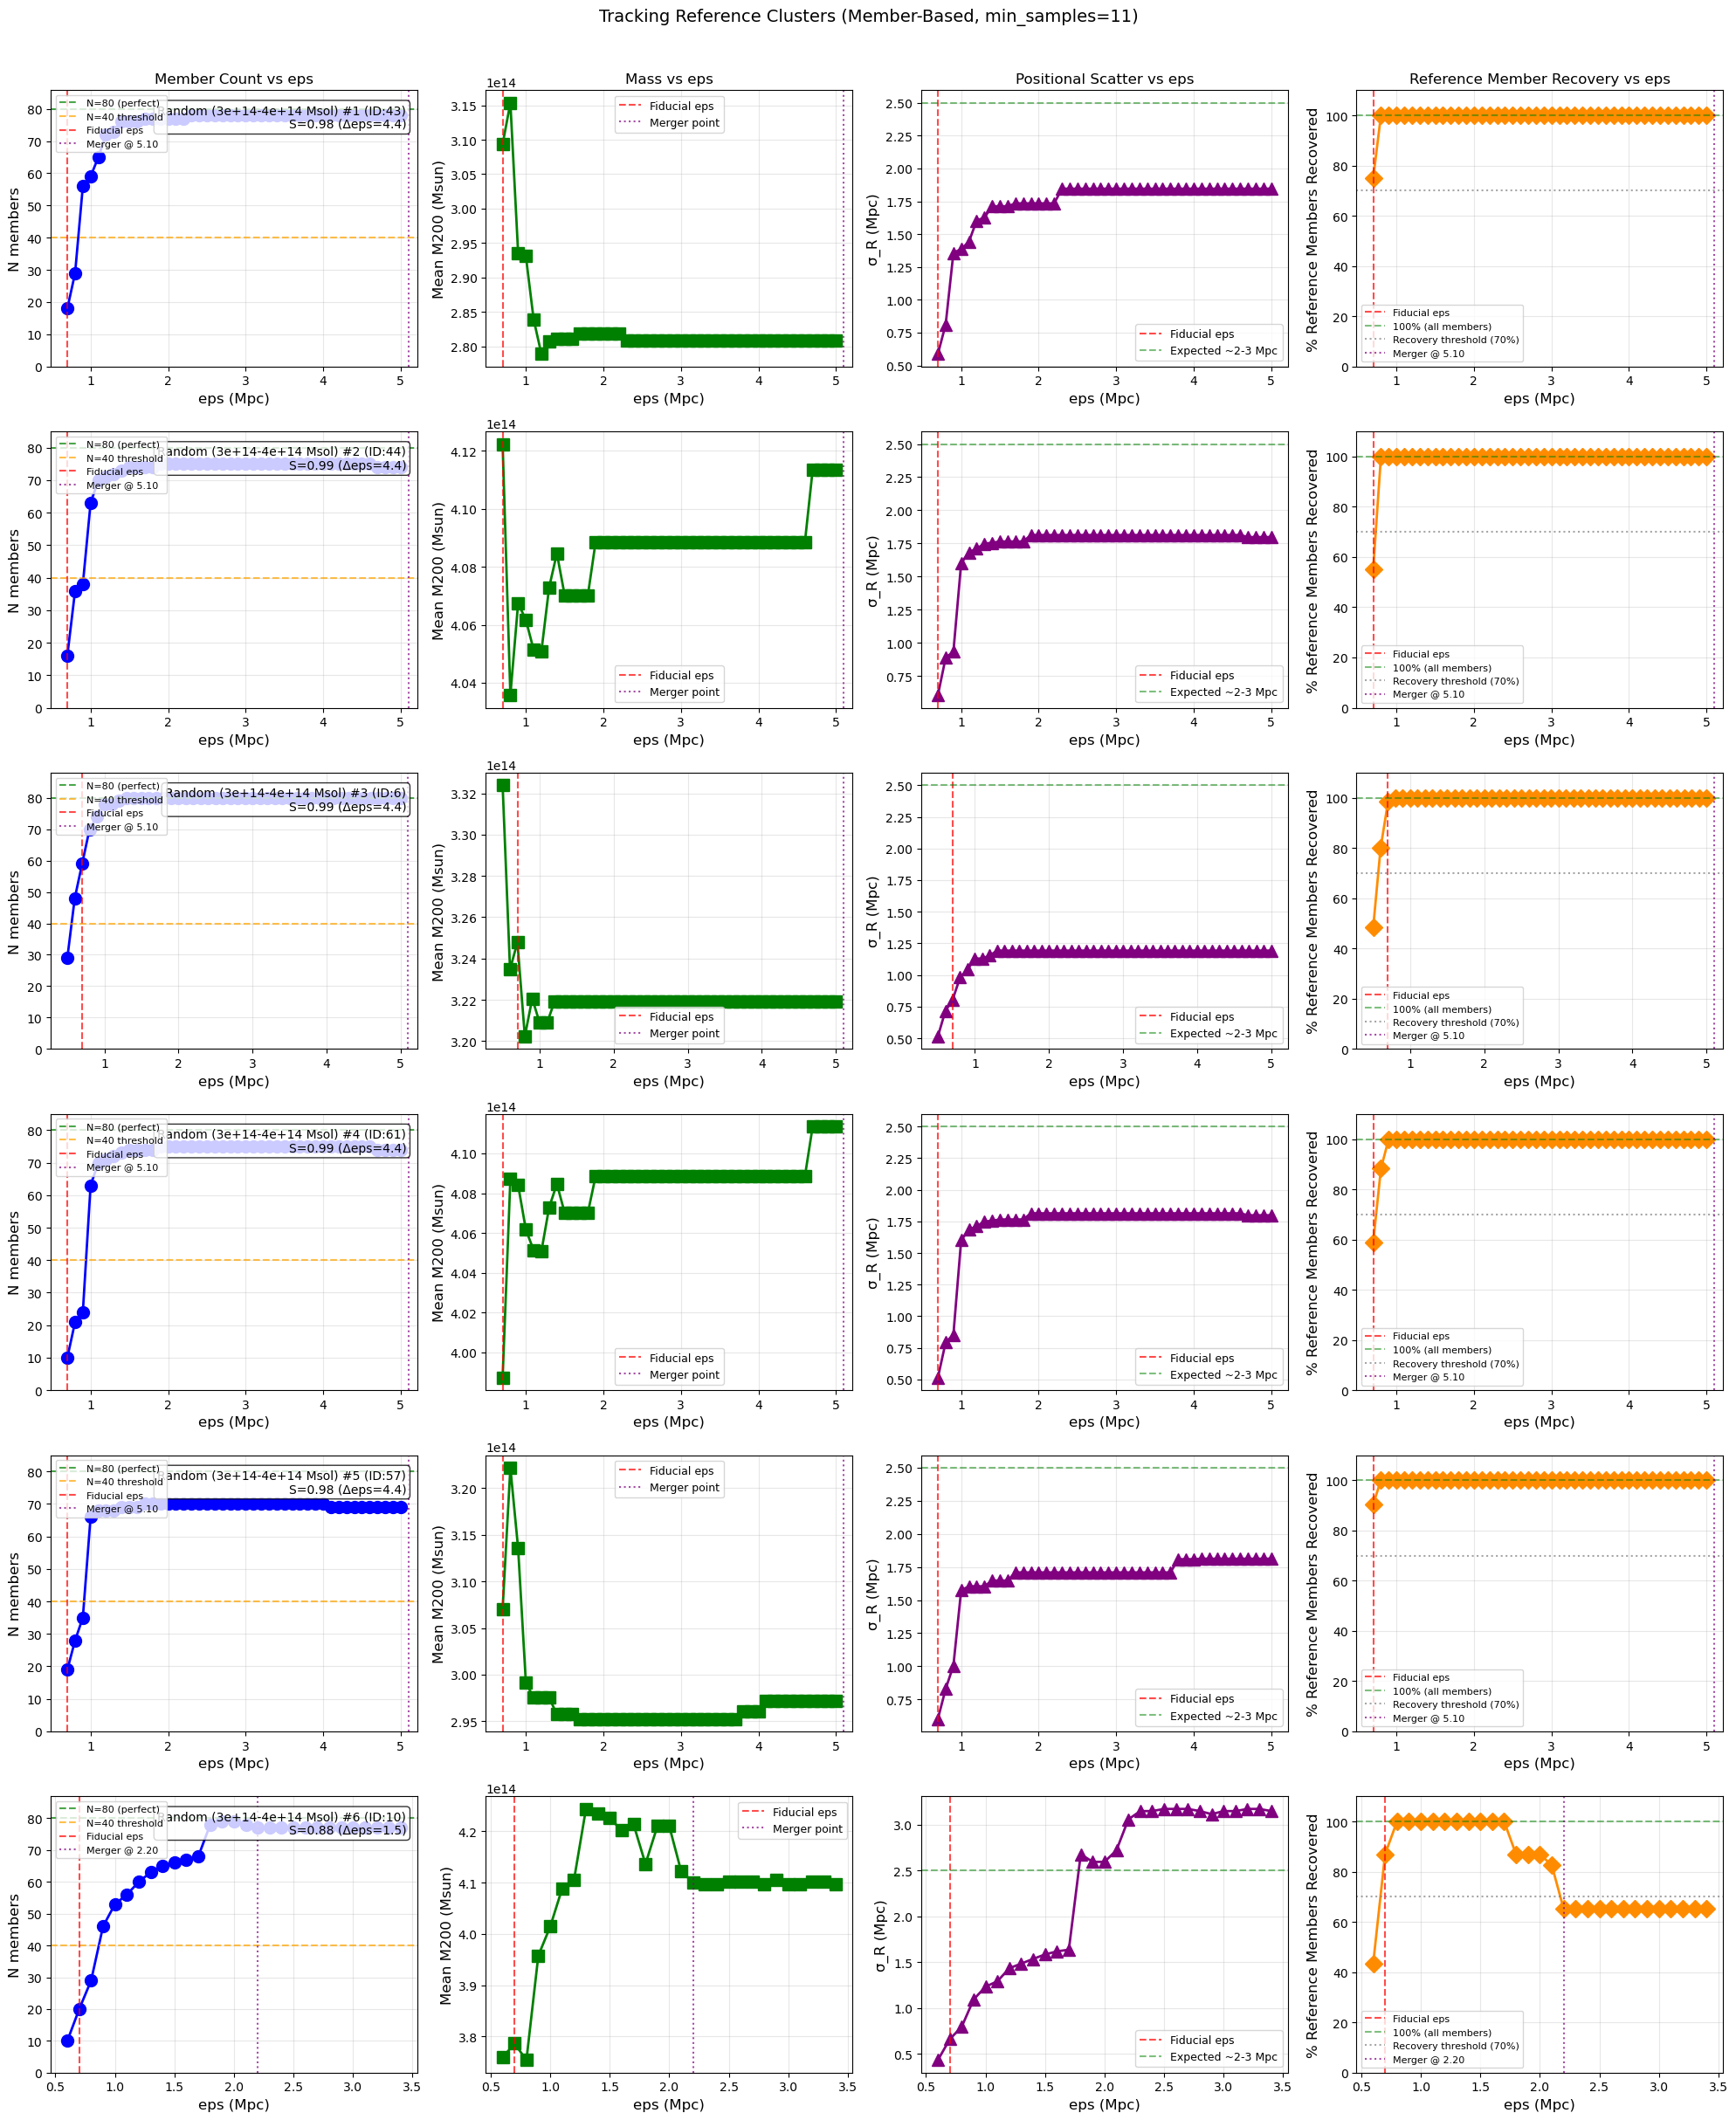


STABILITY SCORE SUMMARY (Upward tracking, cliff detection)
Cluster                                         Score     Δeps     Method    Mass CV   Recovery
----------------------------------------------------------------------------------------------------
Random (3e+14-4e+14 Msol) #1 (ID:43)            0.978     4.40       none      0.025      0.994
Random (3e+14-4e+14 Msol) #2 (ID:44)            0.990     4.40       none      0.004      0.990
Random (3e+14-4e+14 Msol) #3 (ID:6)             0.995     4.40       none      0.002      1.000
Random (3e+14-4e+14 Msol) #4 (ID:61)            0.989     4.40       none      0.005      0.988
Random (3e+14-4e+14 Msol) #5 (ID:57)            0.984     4.40       none      0.017      0.998
Random (3e+14-4e+14 Msol) #6 (ID:10)            0.883     1.50  threshold      0.037      0.954


In [40]:
# Track the selected clusters across different eps values (fixed min_samples)
TRACK_MIN_SAMPLES = 11

# =============================================================================
# TRACKING METHOD CONFIGURATION
# =============================================================================
# Options: "position" or "members"
# - "position": Match by closest mean_position (original method)
# - "members": Match by most shared halo members from reference association
TRACKING_METHOD = "members"

# Stability score configuration (upward tracking only)
# Merger detection: cliff-based (looks for sharp drops)
STABILITY_DROP_THRESHOLD = 0.2      # Detect merger if recovery drops by 20% in one step
STABILITY_MIN_RECOVERY = 0.7        # Also detect if crossing from above to below 70%
STABILITY_MASS_CV_SCALE = 2.0       # Scale for mass CV -> stability conversion
# =============================================================================

# Get eps values for the selected min_samples
eps_for_tracking = sorted([e for e, m in cluster_data.keys() if m == TRACK_MIN_SAMPLES])

# Track each selected cluster
all_tracked_associations = {}
all_stability_scores = {}

for sel_cluster in selected_clusters:
    cluster_name = sel_cluster['name']
    center_position = sel_cluster['position']
    reference_cluster = sel_cluster['cluster']
    
    # Get reference halo IDs for member-based tracking
    reference_halo_ids = get_unique_halo_ids(reference_cluster)
    
    print(f"Tracking {cluster_name} across eps values (min_samples={TRACK_MIN_SAMPLES})")
    print(f"Tracking method: {TRACKING_METHOD}")
    if TRACKING_METHOD == "members":
        print(f"Reference has {len(reference_halo_ids)} unique halo members")
    else:
        print(f"Reference position: [{center_position[0]:.1f}, {center_position[1]:.1f}, {center_position[2]:.1f}]")
    print("="*70)
    
    # Find matching associations at each eps
    tracked_associations = {}
    for eps in eps_for_tracking:
        params = (eps, TRACK_MIN_SAMPLES)
        clusters = cluster_data[params]['clusters']
        
        if TRACKING_METHOD == "members":
            # Member-based matching
            match, n_shared, frac_shared = find_matching_association_by_members(clusters, reference_halo_ids)
            
            if match:
                n_members = len(get_unique_halo_ids(match))
                sigma_r = compute_sigma_r(match)
                
                tracked_associations[eps] = {
                    'cluster': match,
                    'n_shared': n_shared,
                    'frac_shared': frac_shared,
                    'n_members': n_members,
                    'mass': match.get('mean_m200_mass', 0),
                    'sigma_r': sigma_r
                }
                
                print(f"eps={eps:.2f}: ID={match['cluster_id']:3d}, N={n_members:2d}, "
                      f"shared={n_shared:2d}/{len(reference_halo_ids)} ({frac_shared*100:.0f}%), "
                      f"M200={match['mean_m200_mass']:.2e}, σ_R={sigma_r:.2f} Mpc")
            else:
                print(f"eps={eps:.2f}: NO MATCH FOUND (no shared members)")
        else:
            # Position-based matching (original method)
            match, dist = find_matching_association(clusters, center_position)
            
            if match:
                n_members = len(get_unique_halo_ids(match))
                sigma_r = compute_sigma_r(match)
                
                tracked_associations[eps] = {
                    'cluster': match,
                    'distance': dist,
                    'n_members': n_members,
                    'mass': match.get('mean_m200_mass', 0),
                    'sigma_r': sigma_r
                }
                
                print(f"eps={eps:.2f}: ID={match['cluster_id']:3d}, N={n_members:2d}, "
                      f"M200={match['mean_m200_mass']:.2e}, σ_R={sigma_r:.2f} Mpc, offset={dist:.2f} Mpc")
            else:
                print(f"eps={eps:.2f}: NO MATCH FOUND")
    
    all_tracked_associations[cluster_name] = tracked_associations
    
    # Compute stability score (only for member-based tracking)
    if TRACKING_METHOD == "members" and len(tracked_associations) >= 2:
        stability_score, stability_components = compute_stability_score(
            tracked_associations, REFERENCE_EPS, len(reference_halo_ids),
            drop_threshold=STABILITY_DROP_THRESHOLD,
            min_recovery_after=STABILITY_MIN_RECOVERY,
            mass_cv_scale=STABILITY_MASS_CV_SCALE
        )
        all_stability_scores[cluster_name] = {
            'score': stability_score,
            'components': stability_components
        }
        
        print("-" * 70)
        print(f"STABILITY SCORE: {stability_score:.3f}")
        if 'error' not in stability_components:
            print(f"  Components (upward tracking from eps={REFERENCE_EPS}):")
            print(f"    S_merger_distance: {stability_components['S_merger_distance']:.3f} "
                  f"(merger at eps={stability_components['eps_merger']:.2f}, "
                  f"Δeps={stability_components['merger_distance']:.2f} Mpc, "
                  f"detected by: {stability_components['detection_method']})")
            print(f"    S_mass_consistency: {stability_components['S_mass_consistency']:.3f} "
                  f"(CV={stability_components['mass_cv']:.3f})")
            print(f"    S_mean_recovery:    {stability_components['S_mean_recovery']:.3f} "
                  f"(mean in {stability_components['n_eps_plateau']} plateau points)")
        else:
            print(f"  Error: {stability_components['error']}")
    print()

# Create vertically stacked figure with 3 or 4 columns per row (one row per cluster)
n_clusters = len(selected_clusters)
n_cols = 4 if TRACKING_METHOD == "members" else 3
fig, axes = plt.subplots(n_clusters, n_cols, figsize=(5 * n_cols, 4 * n_clusters))

# Handle single cluster case
if n_clusters == 1:
    axes = axes.reshape(1, -1)

for row_idx, sel_cluster in enumerate(selected_clusters):
    cluster_name = sel_cluster['name']
    tracked_associations = all_tracked_associations[cluster_name]
    reference_halo_ids = get_unique_halo_ids(sel_cluster['cluster'])
    
    eps_vals = sorted(tracked_associations.keys())
    n_members = [tracked_associations[e]['n_members'] for e in eps_vals]
    masses = [tracked_associations[e]['mass'] for e in eps_vals]
    sigma_rs = [tracked_associations[e]['sigma_r'] for e in eps_vals]
    
    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]
    ax3 = axes[row_idx, 2]
    
    # Get stability score for title
    stability_info = all_stability_scores.get(cluster_name, {})
    stability_score = stability_info.get('score', None)
    stability_components = stability_info.get('components', {})
    
    # Plot 1: N members vs eps
    ax1.plot(eps_vals, n_members, 'o-', markersize=10, linewidth=2, color='blue')
    ax1.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='N=80 (perfect)')
    ax1.axhline(y=40, color='orange', linestyle='--', alpha=0.7, label='N=40 threshold')
    ax1.axvline(x=REFERENCE_EPS, color='red', linestyle='--', alpha=0.7, label='Fiducial eps')
    # Mark merger point if available
    if 'eps_merger' in stability_components and stability_components.get('merger_distance', 0) > 0:
        ax1.axvline(x=stability_components['eps_merger'], color='purple', linestyle=':', 
                   alpha=0.7, label=f"Merger @ {stability_components['eps_merger']:.2f}")
    ax1.set_xlabel('eps (Mpc)', fontsize=12)
    ax1.set_ylabel('N members', fontsize=12)
    ax1.legend(fontsize=8, loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(85, max(n_members) * 1.1))
    
    # Add cluster name and stability score as text
    label_text = cluster_name
    if stability_score is not None:
        label_text += f"\nS={stability_score:.2f}"
        if 'merger_distance' in stability_components:
            label_text += f" (Δeps={stability_components['merger_distance']:.1f})"
    ax1.text(0.97, 0.95, label_text, transform=ax1.transAxes, fontsize=10, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Plot 2: Mass vs eps
    ax2.plot(eps_vals, masses, 's-', markersize=10, linewidth=2, color='green')
    ax2.axvline(x=REFERENCE_EPS, color='red', linestyle='--', alpha=0.7, label='Fiducial eps')
    if 'eps_merger' in stability_components and stability_components.get('merger_distance', 0) > 0:
        ax2.axvline(x=stability_components['eps_merger'], color='purple', linestyle=':', 
                   alpha=0.7, label='Merger point')
    ax2.set_xlabel('eps (Mpc)', fontsize=12)
    ax2.set_ylabel('Mean M200 (Msun)', fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Plot 3: Positional scatter vs eps
    ax3.plot(eps_vals, sigma_rs, '^-', markersize=10, linewidth=2, color='purple')
    ax3.axvline(x=REFERENCE_EPS, color='red', linestyle='--', alpha=0.7, label='Fiducial eps')
    ax3.axhline(y=2.5, color='green', linestyle='--', alpha=0.5, label='Expected ~2-3 Mpc')
    ax3.set_xlabel('eps (Mpc)', fontsize=12)
    ax3.set_ylabel('σ_R (Mpc)', fontsize=12)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Member overlap (only for member-based tracking)
    if TRACKING_METHOD == "members":
        ax4 = axes[row_idx, 3]
        n_shared = [tracked_associations[e]['n_shared'] for e in eps_vals]
        frac_shared = [tracked_associations[e]['frac_shared'] * 100 for e in eps_vals]
        
        ax4.plot(eps_vals, frac_shared, 'D-', markersize=10, linewidth=2, color='darkorange')
        ax4.axvline(x=REFERENCE_EPS, color='red', linestyle='--', alpha=0.7, label='Fiducial eps')
        ax4.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100% (all members)')
        ax4.axhline(y=STABILITY_MIN_RECOVERY * 100, color='gray', linestyle=':', 
                   alpha=0.7, label=f'Recovery threshold ({STABILITY_MIN_RECOVERY*100:.0f}%)')
        if 'eps_merger' in stability_components and stability_components.get('merger_distance', 0) > 0:
            ax4.axvline(x=stability_components['eps_merger'], color='purple', linestyle=':', 
                       alpha=0.7, label=f"Merger @ {stability_components['eps_merger']:.2f}")
        ax4.set_xlabel('eps (Mpc)', fontsize=12)
        ax4.set_ylabel('% Reference Members Recovered', fontsize=12)
        ax4.legend(fontsize=8, loc='lower left')
        ax4.grid(True, alpha=0.3)
        ax4.set_ylim(0, 110)

# Add column titles only for the first row
axes[0, 0].set_title('Member Count vs eps', fontsize=12)
axes[0, 1].set_title('Mass vs eps', fontsize=12)
axes[0, 2].set_title('Positional Scatter vs eps', fontsize=12)
if TRACKING_METHOD == "members":
    axes[0, 3].set_title('Reference Member Recovery vs eps', fontsize=12)

method_str = "Member-Based" if TRACKING_METHOD == "members" else "Position-Based"
plt.suptitle(f'Tracking Reference Clusters ({method_str}, min_samples={TRACK_MIN_SAMPLES})', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table of stability scores
if all_stability_scores:
    print("\n" + "="*100)
    print("STABILITY SCORE SUMMARY (Upward tracking, cliff detection)")
    print("="*100)
    print(f"{'Cluster':<45} {'Score':>7} {'Δeps':>8} {'Method':>10} {'Mass CV':>10} {'Recovery':>10}")
    print("-"*100)
    for name, info in all_stability_scores.items():
        score = info['score']
        comp = info['components']
        if 'error' not in comp:
            print(f"{name:<45} {score:>7.3f} {comp['merger_distance']:>8.2f} "
                  f"{comp['detection_method']:>10} {comp['mass_cv']:>10.3f} {comp['S_mean_recovery']:>10.3f}")
        else:
            print(f"{name:<45} {score:>7.3f} {'N/A':>8} {'N/A':>10} {'N/A':>10} {'N/A':>10} ({comp['error']})")
    print("="*100)

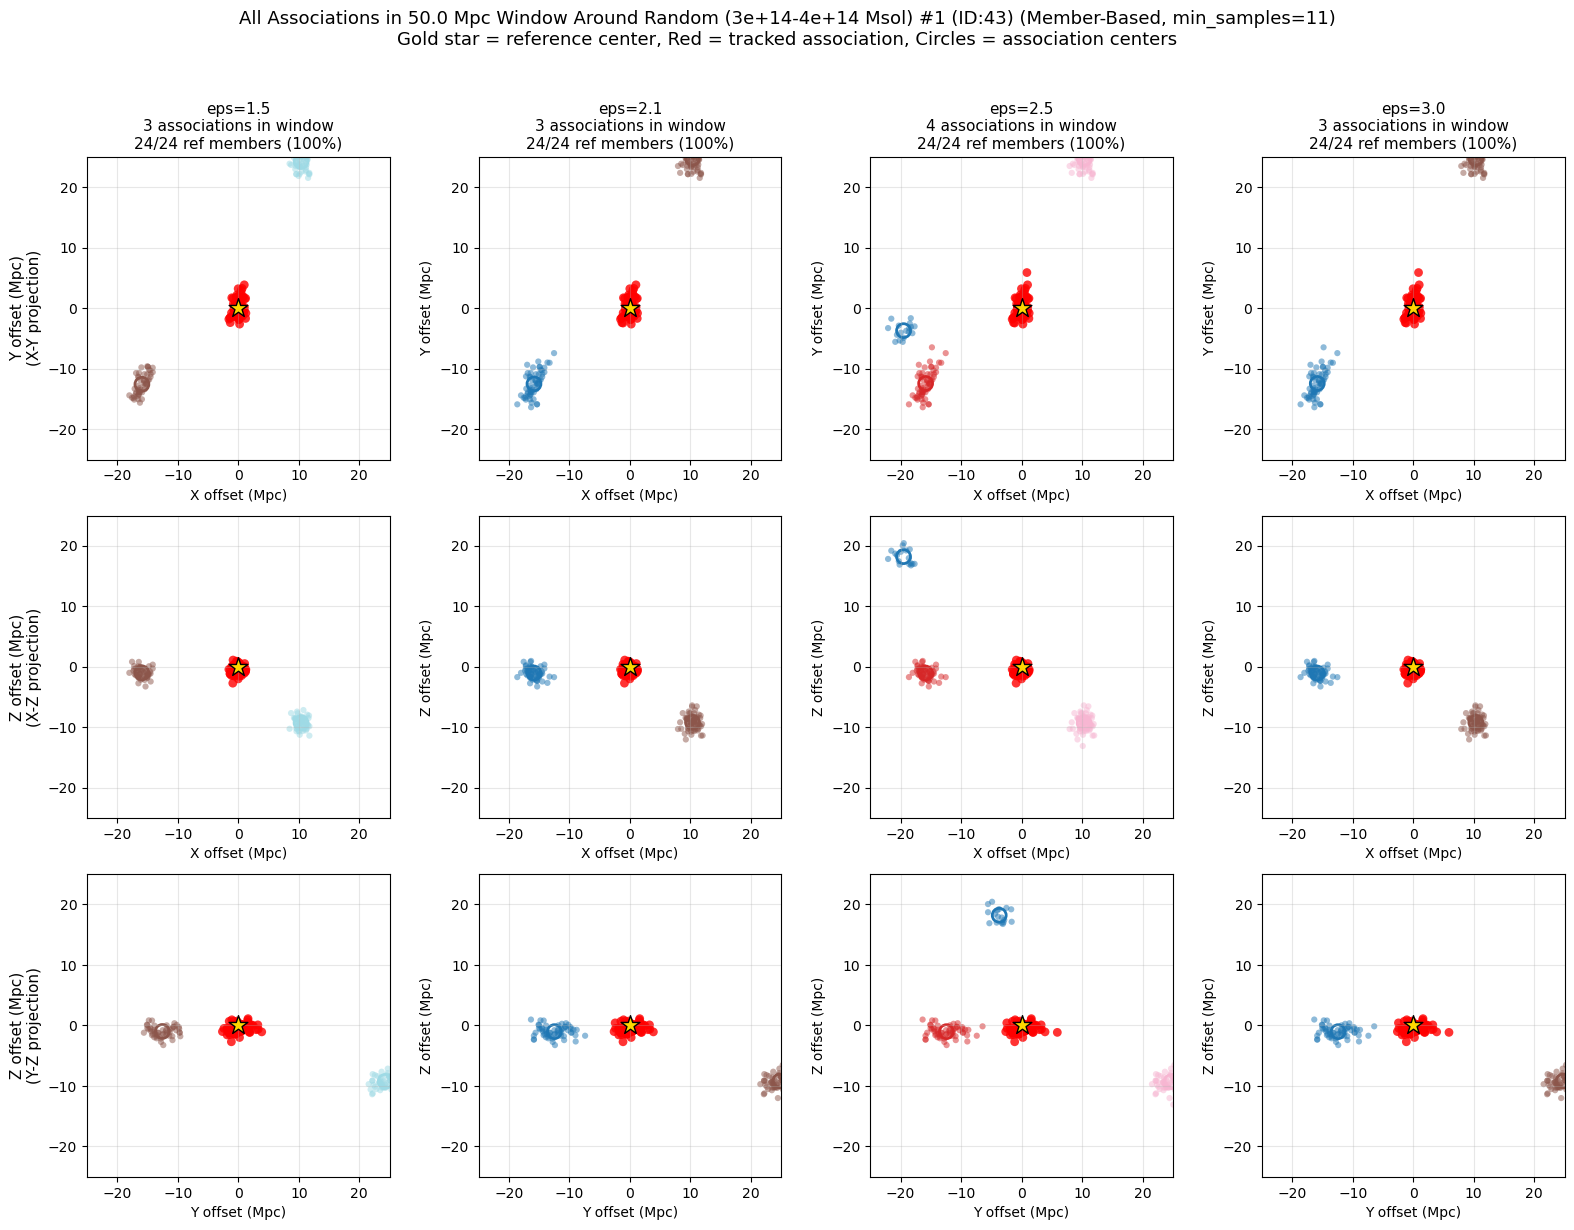


Associations in window at each eps for Random (3e+14-4e+14 Msol) #1 (ID:43):
  eps=1.5: 3 associations
  eps=2.1: 3 associations
  eps=2.5: 4 associations
  eps=3.0: 3 associations



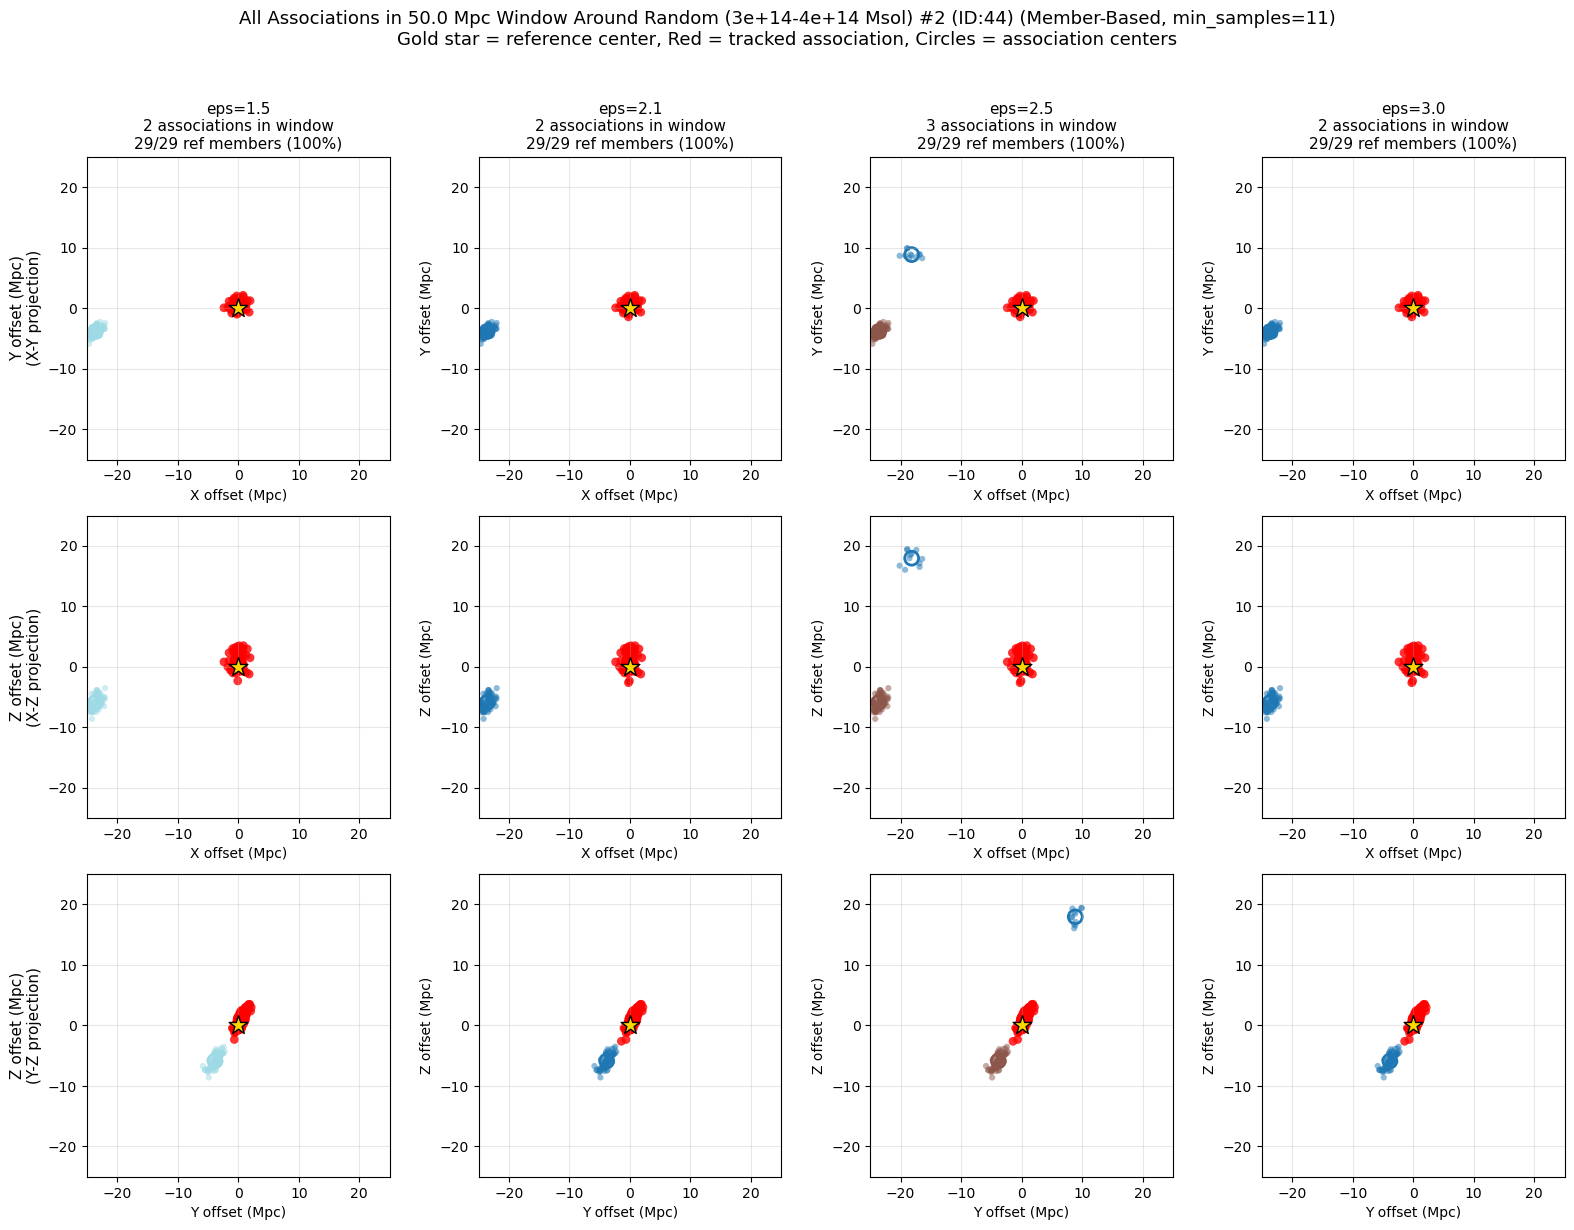


Associations in window at each eps for Random (3e+14-4e+14 Msol) #2 (ID:44):
  eps=1.5: 2 associations
  eps=2.1: 2 associations
  eps=2.5: 3 associations
  eps=3.0: 2 associations



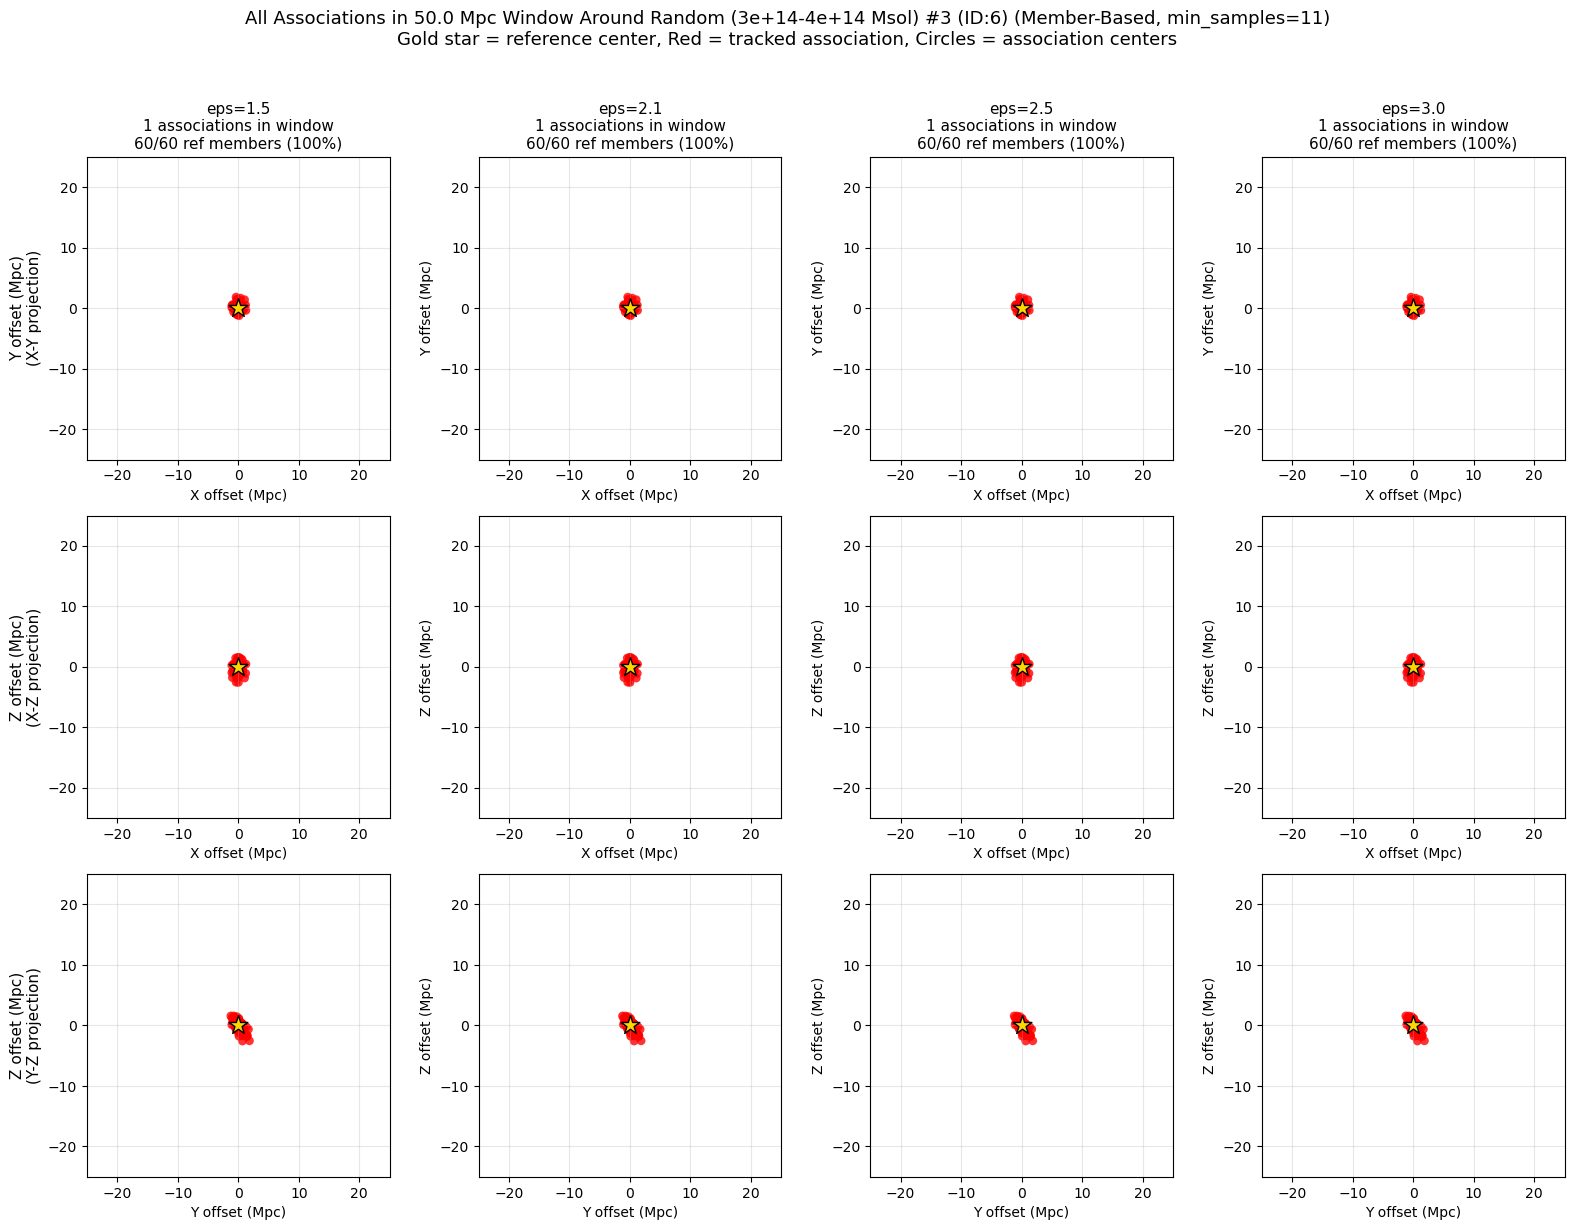


Associations in window at each eps for Random (3e+14-4e+14 Msol) #3 (ID:6):
  eps=1.5: 1 associations
  eps=2.1: 1 associations
  eps=2.5: 1 associations
  eps=3.0: 1 associations



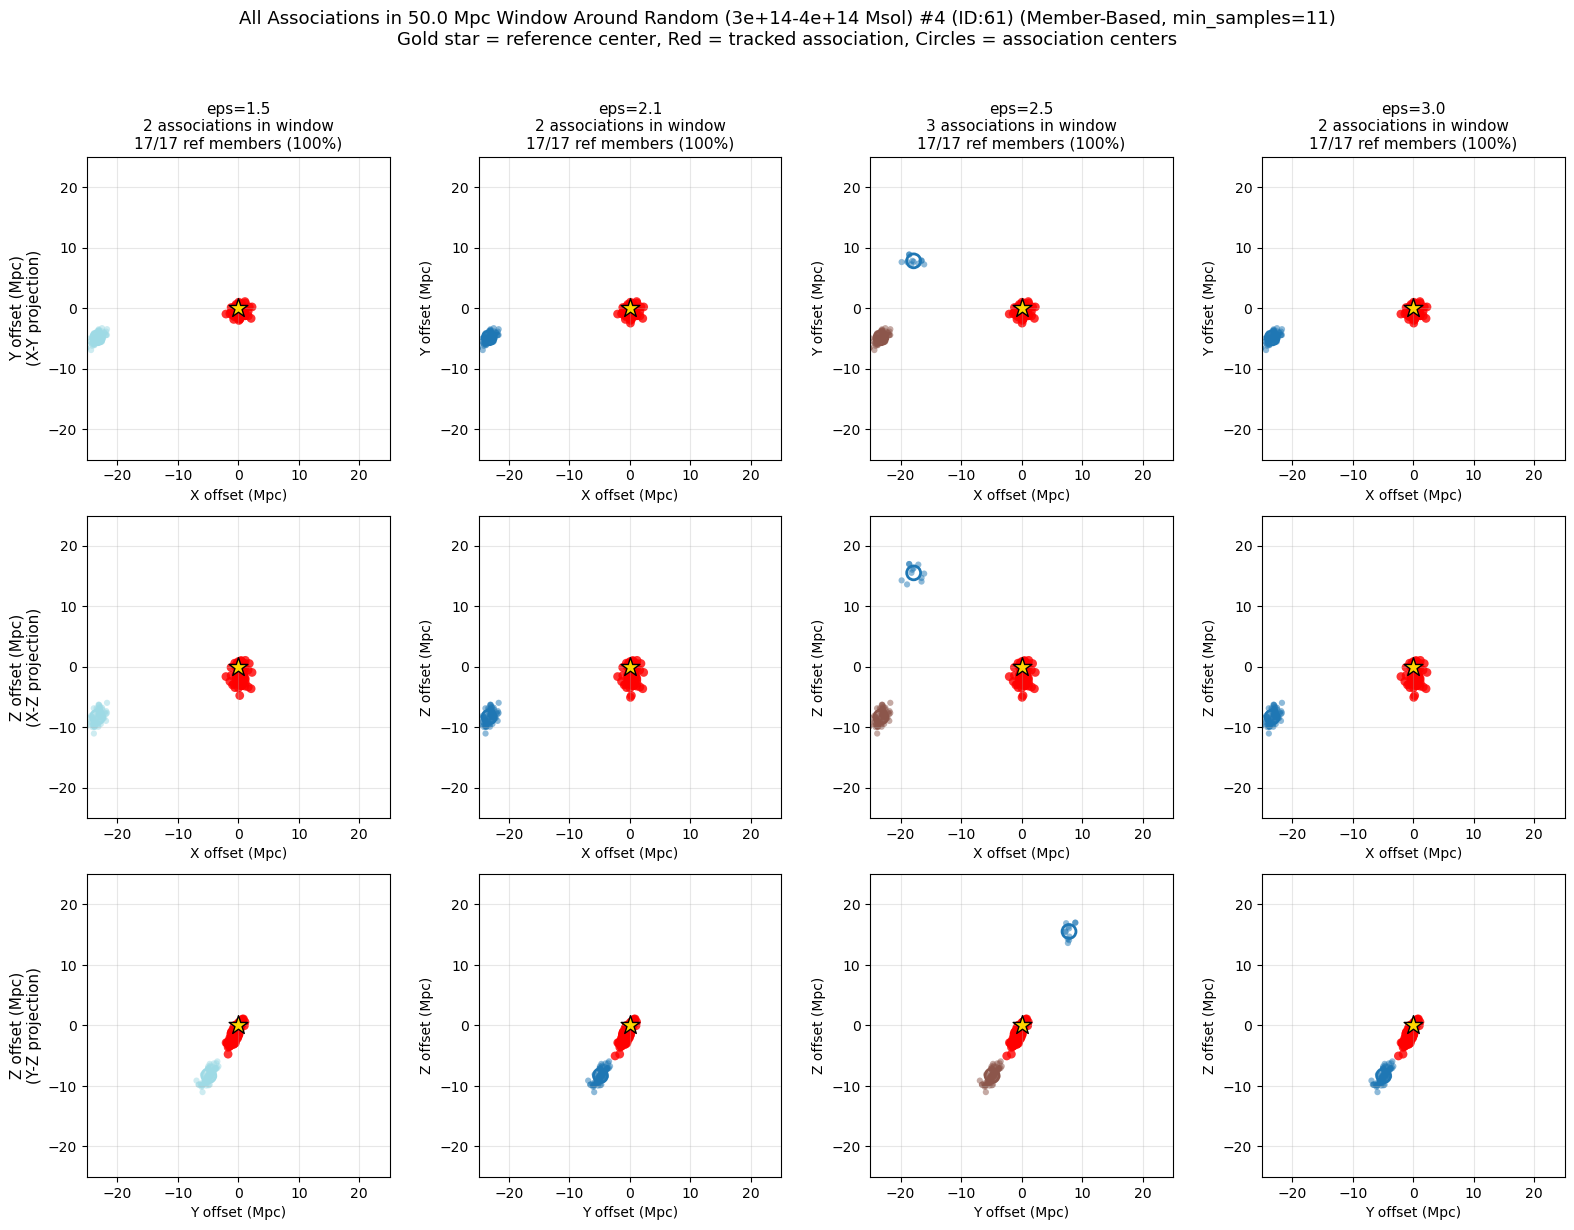


Associations in window at each eps for Random (3e+14-4e+14 Msol) #4 (ID:61):
  eps=1.5: 2 associations
  eps=2.1: 2 associations
  eps=2.5: 3 associations
  eps=3.0: 2 associations



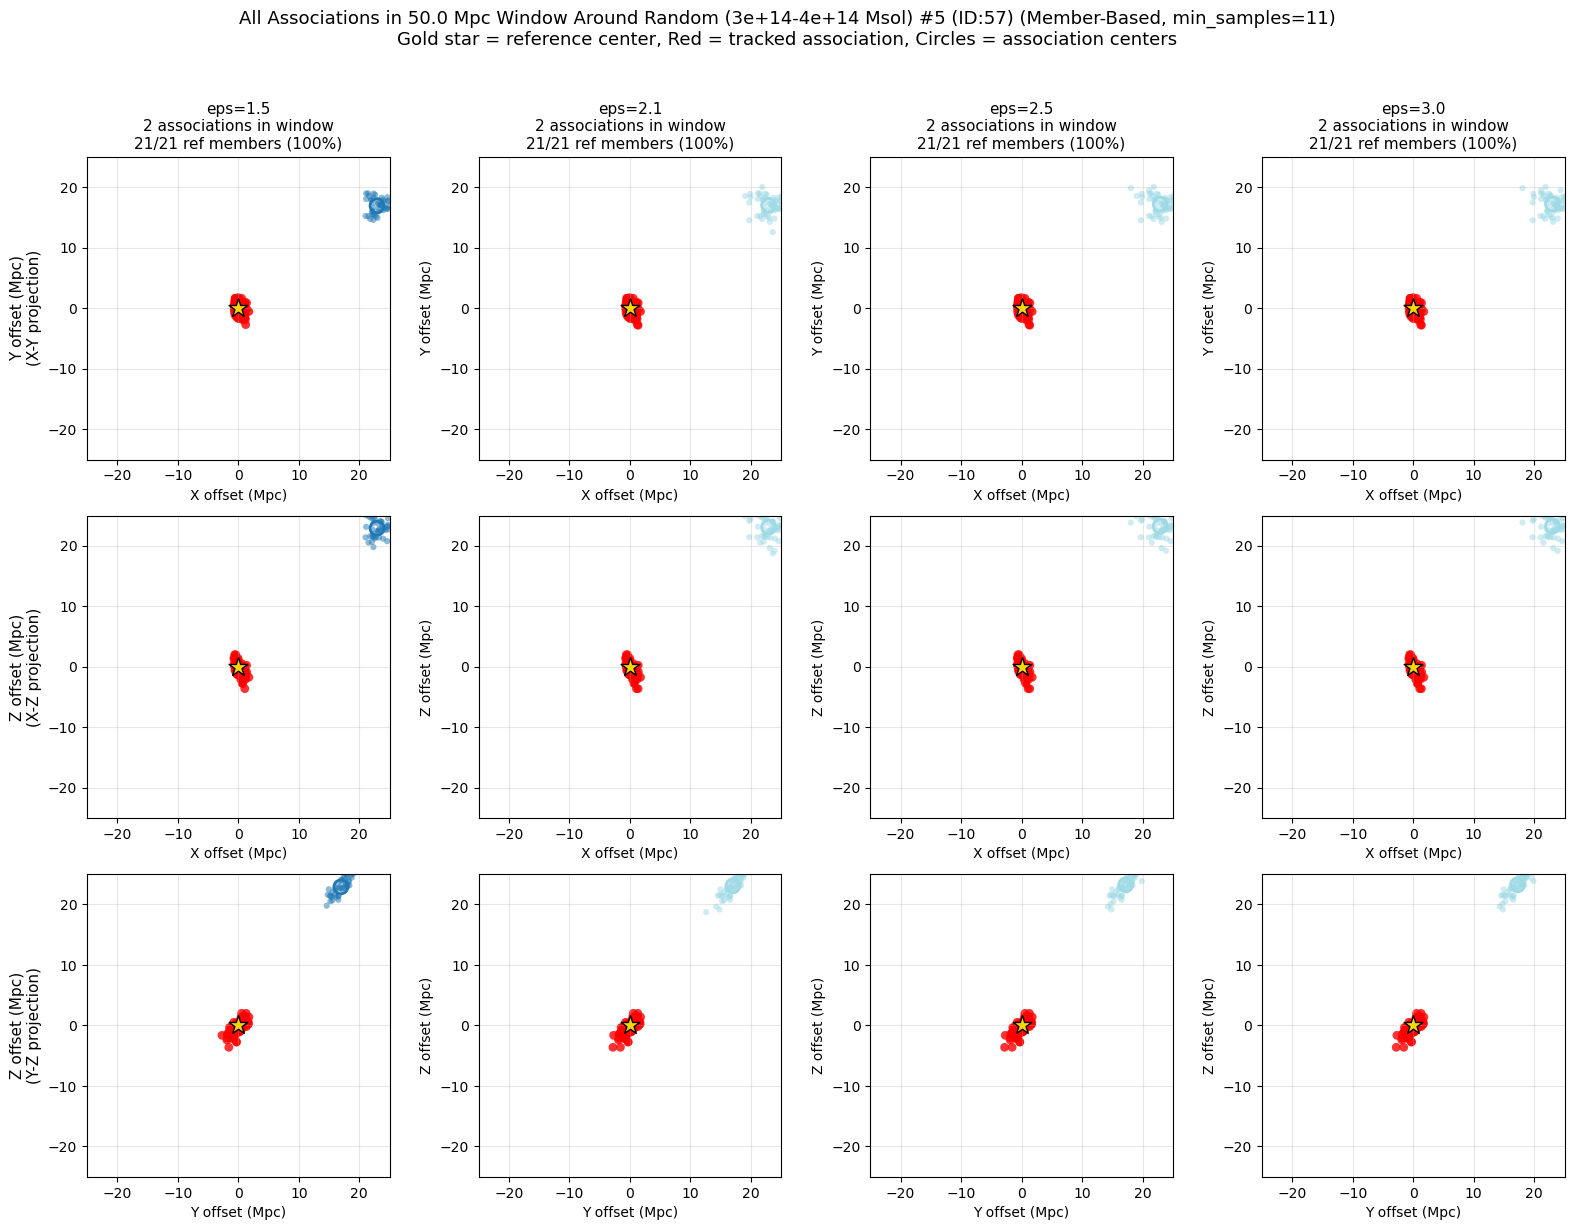


Associations in window at each eps for Random (3e+14-4e+14 Msol) #5 (ID:57):
  eps=1.5: 2 associations
  eps=2.1: 2 associations
  eps=2.5: 2 associations
  eps=3.0: 2 associations



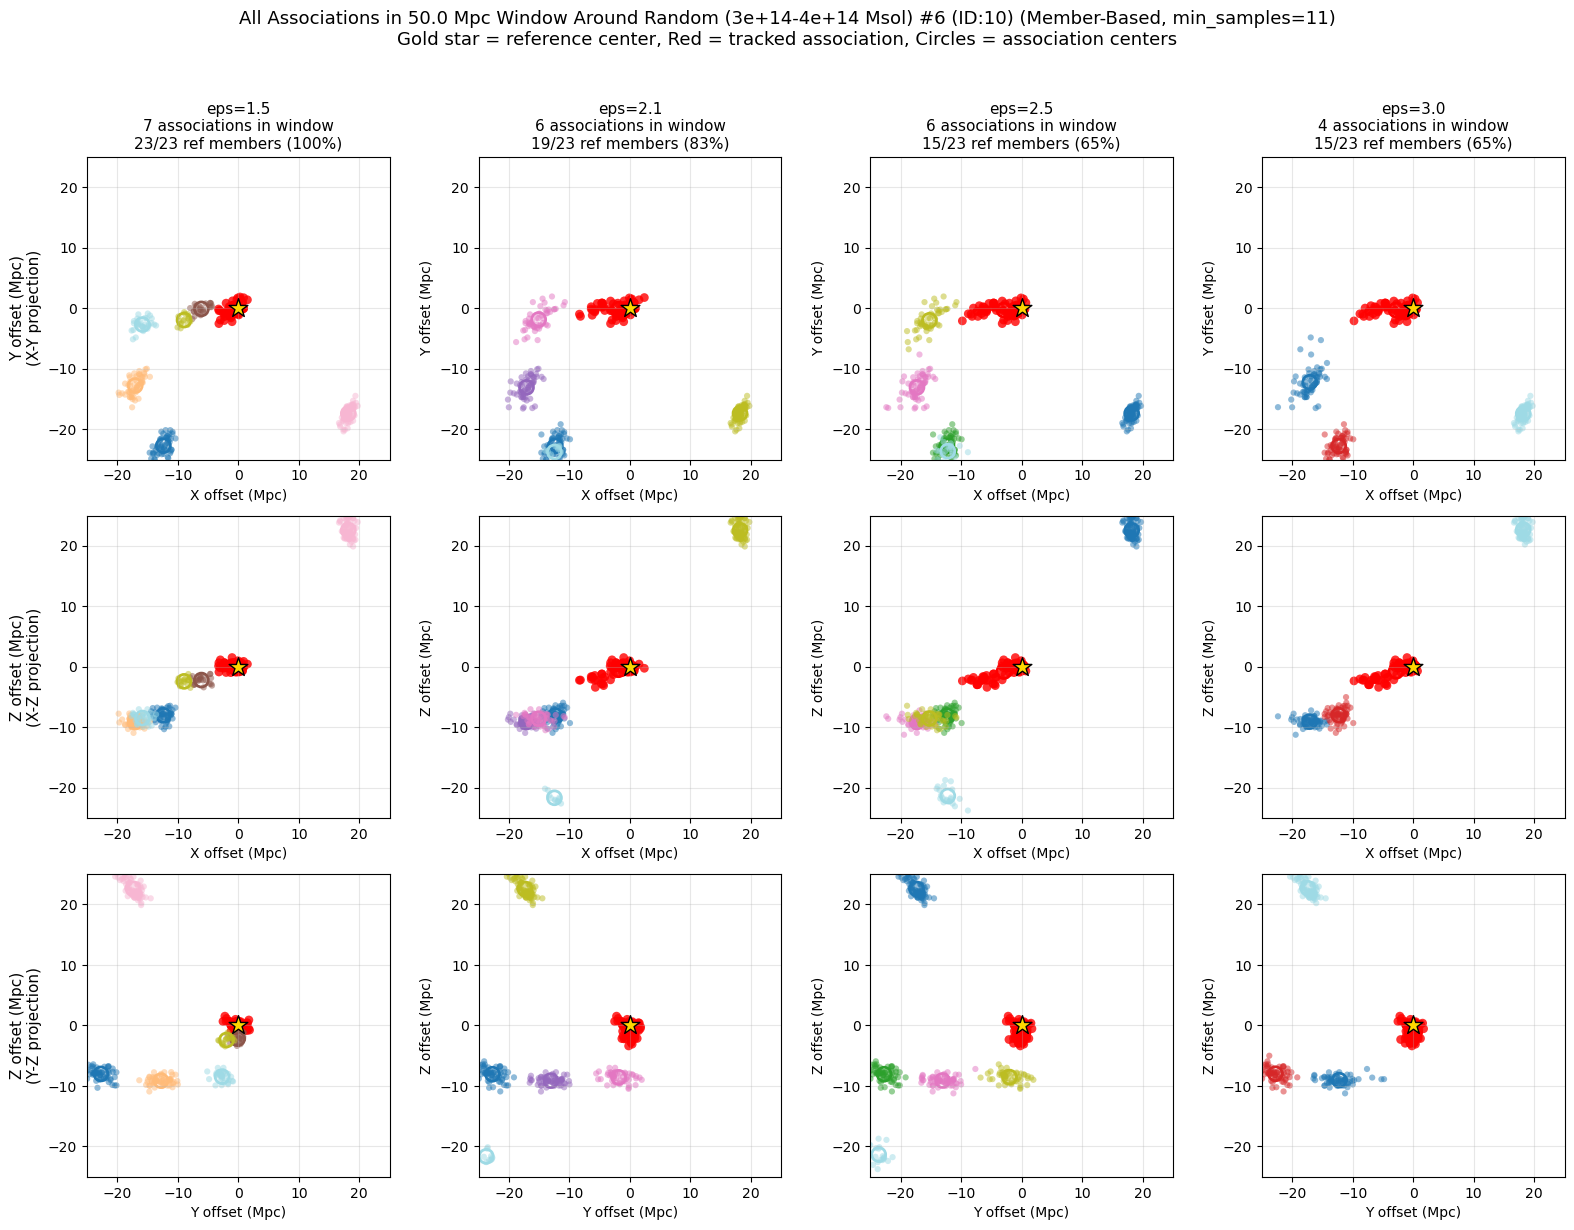


Associations in window at each eps for Random (3e+14-4e+14 Msol) #6 (ID:10):
  eps=1.5: 7 associations
  eps=2.1: 6 associations
  eps=2.5: 6 associations
  eps=3.0: 4 associations



In [41]:
# Visualize all associations within the window at different eps values for each reference cluster
# Each association's members are uniquely colored

eps_to_show = [1.25, 1.5, 1.75, 2.1, 2.5, 3.0]

ZOOM_SIZE = 50.0  # Mpc - window size

# Create a separate figure for each reference cluster
for sel_cluster in selected_clusters:
    cluster_name = sel_cluster['name']
    center_position = sel_cluster['position']
    tracked_associations = all_tracked_associations[cluster_name]
    reference_halo_ids = get_unique_halo_ids(sel_cluster['cluster'])
    
    # Filter eps values to those with tracked associations
    eps_for_plot = [e for e in eps_to_show if e in tracked_associations]
    
    if len(eps_for_plot) == 0:
        print(f"No tracked associations found for {cluster_name}, skipping spatial plot")
        continue
    
    fig, axes = plt.subplots(3, len(eps_for_plot), figsize=(4 * len(eps_for_plot), 12))
    
    # Handle single eps case
    if len(eps_for_plot) == 1:
        axes = axes.reshape(-1, 1)
    
    for col_idx, eps in enumerate(eps_for_plot):
        params = (eps, TRACK_MIN_SAMPLES)
        all_clusters = cluster_data[params]['clusters']
        
        # Get the tracked association at this eps (use member-based if available)
        tracked_info = tracked_associations.get(eps, {})
        tracked_cluster = tracked_info.get('cluster', None)
        tracked_halo_ids = get_unique_halo_ids(tracked_cluster) if tracked_cluster else set()
        
        # Find all associations with mean position within the window
        associations_in_window = []
        for cluster in all_clusters:
            pos = np.array(cluster['mean_position'])
            offset = pos - np.array(center_position)
            # Check if within window bounds
            if (abs(offset[0]) <= ZOOM_SIZE/2 and 
                abs(offset[1]) <= ZOOM_SIZE/2 and 
                abs(offset[2]) <= ZOOM_SIZE/2):
                associations_in_window.append(cluster)
        
        # Generate unique colors for each association
        n_assoc = len(associations_in_window)
        assoc_colors = plt.cm.tab20(np.linspace(0, 1, max(n_assoc, 1)))
        
        ax1 = axes[0, col_idx]  # X-Y
        ax2 = axes[1, col_idx]  # X-Z
        ax3 = axes[2, col_idx]  # Y-Z
        
        # Plot each association's members
        for assoc_idx, cluster in enumerate(associations_in_window):
            member_data = cluster.get('member_data', {})
            positions = member_data.get('SO/200/crit/CentreOfMass', None)
            
            if positions is None:
                continue
            
            # Offset positions relative to the reference center
            offsets = positions - np.array(center_position)
            
            # Check if this is the tracked association
            is_tracked = (tracked_cluster is not None and 
                         cluster['cluster_id'] == tracked_cluster['cluster_id'])
            
            color = 'red' if is_tracked else assoc_colors[assoc_idx]
            alpha = 0.8 if is_tracked else 0.5
            size = 40 if is_tracked else 20
            
            # X-Y projection (top row)
            ax1.scatter(offsets[:, 0], offsets[:, 1], s=size, alpha=alpha, 
                        color=color, edgecolors='none')
            
            # X-Z projection (middle row)
            ax2.scatter(offsets[:, 0], offsets[:, 2], s=size, alpha=alpha, 
                        color=color, edgecolors='none')
            
            # Y-Z projection (bottom row)
            ax3.scatter(offsets[:, 1], offsets[:, 2], s=size, alpha=alpha, 
                        color=color, edgecolors='none')
            
            # Mark association center
            assoc_offset = np.array(cluster['mean_position']) - np.array(center_position)
            marker_color = 'red' if is_tracked else color
            ax1.scatter([assoc_offset[0]], [assoc_offset[1]], s=100, marker='o', 
                        facecolors='none', edgecolors=marker_color, linewidths=2)
            ax2.scatter([assoc_offset[0]], [assoc_offset[2]], s=100, marker='o', 
                        facecolors='none', edgecolors=marker_color, linewidths=2)
            ax3.scatter([assoc_offset[1]], [assoc_offset[2]], s=100, marker='o', 
                        facecolors='none', edgecolors=marker_color, linewidths=2)
        
        # Mark the reference center (original position from fiducial params)
        ax1.scatter([0], [0], c='gold', s=200, marker='*', zorder=10, edgecolors='black')
        ax2.scatter([0], [0], c='gold', s=200, marker='*', zorder=10, edgecolors='black')
        ax3.scatter([0], [0], c='gold', s=200, marker='*', zorder=10, edgecolors='black')
        
        # Get tracked association info for title
        n_members = tracked_info.get('n_members', '?')
        sigma_r = tracked_info.get('sigma_r', 0)
        
        # Add member recovery info if using member-based tracking
        title_extra = ""
        if TRACKING_METHOD == "members" and 'frac_shared' in tracked_info:
            frac = tracked_info['frac_shared'] * 100
            n_shared = tracked_info['n_shared']
            title_extra = f"\n{n_shared}/{len(reference_halo_ids)} ref members ({frac:.0f}%)"
        
        # Configure X-Y plot
        ax1.set_xlim(-ZOOM_SIZE/2, ZOOM_SIZE/2)
        ax1.set_ylim(-ZOOM_SIZE/2, ZOOM_SIZE/2)
        ax1.set_xlabel('X offset (Mpc)', fontsize=10)
        ax1.set_ylabel('Y offset (Mpc)', fontsize=10)
        ax1.set_title(f'eps={eps}\n{n_assoc} associations in window{title_extra}', fontsize=11)
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)
        
        # Configure X-Z plot
        ax2.set_xlim(-ZOOM_SIZE/2, ZOOM_SIZE/2)
        ax2.set_ylim(-ZOOM_SIZE/2, ZOOM_SIZE/2)
        ax2.set_xlabel('X offset (Mpc)', fontsize=10)
        ax2.set_ylabel('Z offset (Mpc)', fontsize=10)
        ax2.set_aspect('equal')
        ax2.grid(True, alpha=0.3)
        
        # Configure Y-Z plot
        ax3.set_xlim(-ZOOM_SIZE/2, ZOOM_SIZE/2)
        ax3.set_ylim(-ZOOM_SIZE/2, ZOOM_SIZE/2)
        ax3.set_xlabel('Y offset (Mpc)', fontsize=10)
        ax3.set_ylabel('Z offset (Mpc)', fontsize=10)
        ax3.set_aspect('equal')
        ax3.grid(True, alpha=0.3)
    
    # Row labels
    axes[0, 0].set_ylabel('Y offset (Mpc)\n(X-Y projection)', fontsize=11)
    axes[1, 0].set_ylabel('Z offset (Mpc)\n(X-Z projection)', fontsize=11)
    axes[2, 0].set_ylabel('Z offset (Mpc)\n(Y-Z projection)', fontsize=11)
    
    method_str = "Member-Based" if TRACKING_METHOD == "members" else "Position-Based"
    plt.suptitle(f'All Associations in {ZOOM_SIZE} Mpc Window Around {cluster_name} ({method_str}, min_samples={TRACK_MIN_SAMPLES})\n'
                 f'Gold star = reference center, Red = tracked association, Circles = association centers',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAssociations in window at each eps for {cluster_name}:")
    for eps in eps_for_plot:
        params = (eps, TRACK_MIN_SAMPLES)
        all_clusters_eps = cluster_data[params]['clusters']
        n_in_window = sum(1 for c in all_clusters_eps 
                          if all(abs(c['mean_position'][i] - center_position[i]) <= ZOOM_SIZE/2 
                                 for i in range(3)))
        print(f"  eps={eps}: {n_in_window} associations")
    print()

---
# Plotting Section 3: Stability Analysis

Compute stability scores for all associations at the fiducial parameters and analyze the distribution.

In [34]:
# =============================================================================
# COMPUTE STABILITY FOR ALL ASSOCIATIONS AT FIDUCIAL PARAMETERS
# =============================================================================
# This cell computes stability scores for every association at the fiducial
# eps and min_samples, then analyzes the distribution.
# Stability is computed by tracking UPWARD from fiducial eps only.
# Mergers are detected using cliff detection (sharp drops in recovery).

# Configuration
STABILITY_FIDUCIAL_EPS = REFERENCE_EPS          # Use same as tracking
STABILITY_FIDUCIAL_MIN_SAMPLES = REFERENCE_NUM_SAMPLES
STABILITY_TRACK_MIN_SAMPLES = TRACK_MIN_SAMPLES  # min_samples for tracking across eps
STABILITY_MIN_MEMBERS = 10                       # Minimum members to include in analysis

# Use same thresholds as cell 22 (cliff detection parameters)
STABILITY_DROP_THR = STABILITY_DROP_THRESHOLD    # Detect merger if recovery drops by this much
STABILITY_MIN_REC = STABILITY_MIN_RECOVERY       # Also detect if crossing this threshold
STABILITY_MASS_CV = STABILITY_MASS_CV_SCALE

print(f"Computing stability for all associations at eps={STABILITY_FIDUCIAL_EPS}, "
      f"min_samples={STABILITY_FIDUCIAL_MIN_SAMPLES}")
print(f"Tracking UPWARD across eps values with min_samples={STABILITY_TRACK_MIN_SAMPLES}")
print(f"Cliff detection: drop >= {STABILITY_DROP_THR*100:.0f}% or crossing {STABILITY_MIN_REC*100:.0f}% recovery")
print(f"Mass CV scale: {STABILITY_MASS_CV}")
print(f"Minimum members filter: {STABILITY_MIN_MEMBERS}")
print("="*80)

# Get reference associations
fiducial_params = (STABILITY_FIDUCIAL_EPS, STABILITY_FIDUCIAL_MIN_SAMPLES)
if fiducial_params not in cluster_data:
    print(f"ERROR: Fiducial parameters {fiducial_params} not found in cluster_data!")
else:
    fiducial_clusters = cluster_data[fiducial_params]['clusters']
    
    # Filter by minimum members
    clusters_to_analyze = [c for c in fiducial_clusters 
                          if len(get_unique_halo_ids(c)) >= STABILITY_MIN_MEMBERS]
    
    print(f"Total associations at fiducial: {len(fiducial_clusters)}")
    print(f"Associations with >= {STABILITY_MIN_MEMBERS} members: {len(clusters_to_analyze)}")
    print()
    
    # Compute stability for each association
    all_stabilities = []
    
    for i, cluster in enumerate(clusters_to_analyze):
        cluster_id = cluster['cluster_id']
        mass = cluster.get('mean_m200_mass', 0)
        n_members = len(get_unique_halo_ids(cluster))
        
        # Compute stability (upward tracking only, cliff-based merger detection)
        score, components, tracked = compute_stability_for_association(
            cluster, cluster_data, STABILITY_FIDUCIAL_EPS, 
            STABILITY_TRACK_MIN_SAMPLES, 
            drop_threshold=STABILITY_DROP_THR,
            min_recovery_after=STABILITY_MIN_REC,
            mass_cv_scale=STABILITY_MASS_CV
        )
        
        all_stabilities.append({
            'cluster_id': cluster_id,
            'mass': mass,
            'n_members': n_members,
            'stability': score,
            'components': components,
            'n_eps_tracked': len(tracked)
        })
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(clusters_to_analyze)} associations...")
    
    print(f"\nCompleted stability computation for {len(all_stabilities)} associations")
    
    # Convert to arrays for analysis
    stabilities = np.array([s['stability'] for s in all_stabilities])
    masses = np.array([s['mass'] for s in all_stabilities])
    n_members_arr = np.array([s['n_members'] for s in all_stabilities])
    
    # Extract merger distances for associations with valid scores
    merger_distances = []
    for s in all_stabilities:
        comp = s['components']
        if 'merger_distance' in comp:
            merger_distances.append(comp['merger_distance'])
        else:
            merger_distances.append(np.nan)
    merger_distances = np.array(merger_distances)
    
    # Summary statistics
    print("\n" + "="*80)
    print("STABILITY DISTRIBUTION SUMMARY")
    print("="*80)
    print(f"Mean stability:   {np.mean(stabilities):.3f}")
    print(f"Median stability: {np.median(stabilities):.3f}")
    print(f"Std stability:    {np.std(stabilities):.3f}")
    print(f"Min stability:    {np.min(stabilities):.3f}")
    print(f"Max stability:    {np.max(stabilities):.3f}")
    print()
    print("Stability distribution:")
    print(f"  S >= 0.8 (very stable):     {np.sum(stabilities >= 0.8):3d} ({100*np.mean(stabilities >= 0.8):.1f}%)")
    print(f"  0.6 <= S < 0.8 (stable):    {np.sum((stabilities >= 0.6) & (stabilities < 0.8)):3d} ({100*np.mean((stabilities >= 0.6) & (stabilities < 0.8)):.1f}%)")
    print(f"  0.4 <= S < 0.6 (moderate):  {np.sum((stabilities >= 0.4) & (stabilities < 0.6)):3d} ({100*np.mean((stabilities >= 0.4) & (stabilities < 0.6)):.1f}%)")
    print(f"  S < 0.4 (unstable):         {np.sum(stabilities < 0.4):3d} ({100*np.mean(stabilities < 0.4):.1f}%)")
    print()
    valid_merger = ~np.isnan(merger_distances)
    if valid_merger.sum() > 0:
        print("Merger distance (Δeps from fiducial to merger):")
        print(f"  Mean:   {np.nanmean(merger_distances):.2f} Mpc")
        print(f"  Median: {np.nanmedian(merger_distances):.2f} Mpc")
        print(f"  Min:    {np.nanmin(merger_distances):.2f} Mpc")
        print(f"  Max:    {np.nanmax(merger_distances):.2f} Mpc")
    print("="*80)

Computing stability for all associations at eps=2.1, min_samples=9
Tracking UPWARD across eps values with min_samples=11
Cliff detection: drop >= 20% or crossing 70% recovery
Mass CV scale: 2.0
Minimum members filter: 10
Total associations at fiducial: 644
Associations with >= 10 members: 644

  Processed 50/644 associations...
  Processed 100/644 associations...
  Processed 150/644 associations...
  Processed 200/644 associations...
  Processed 250/644 associations...
  Processed 300/644 associations...
  Processed 350/644 associations...
  Processed 400/644 associations...
  Processed 450/644 associations...
  Processed 500/644 associations...
  Processed 550/644 associations...
  Processed 600/644 associations...

Completed stability computation for 644 associations

STABILITY DISTRIBUTION SUMMARY
Mean stability:   0.854
Median stability: 0.886
Std stability:    0.113
Min stability:    0.408
Max stability:    0.983

Stability distribution:
  S >= 0.8 (very stable):     485 (75.3%)
 

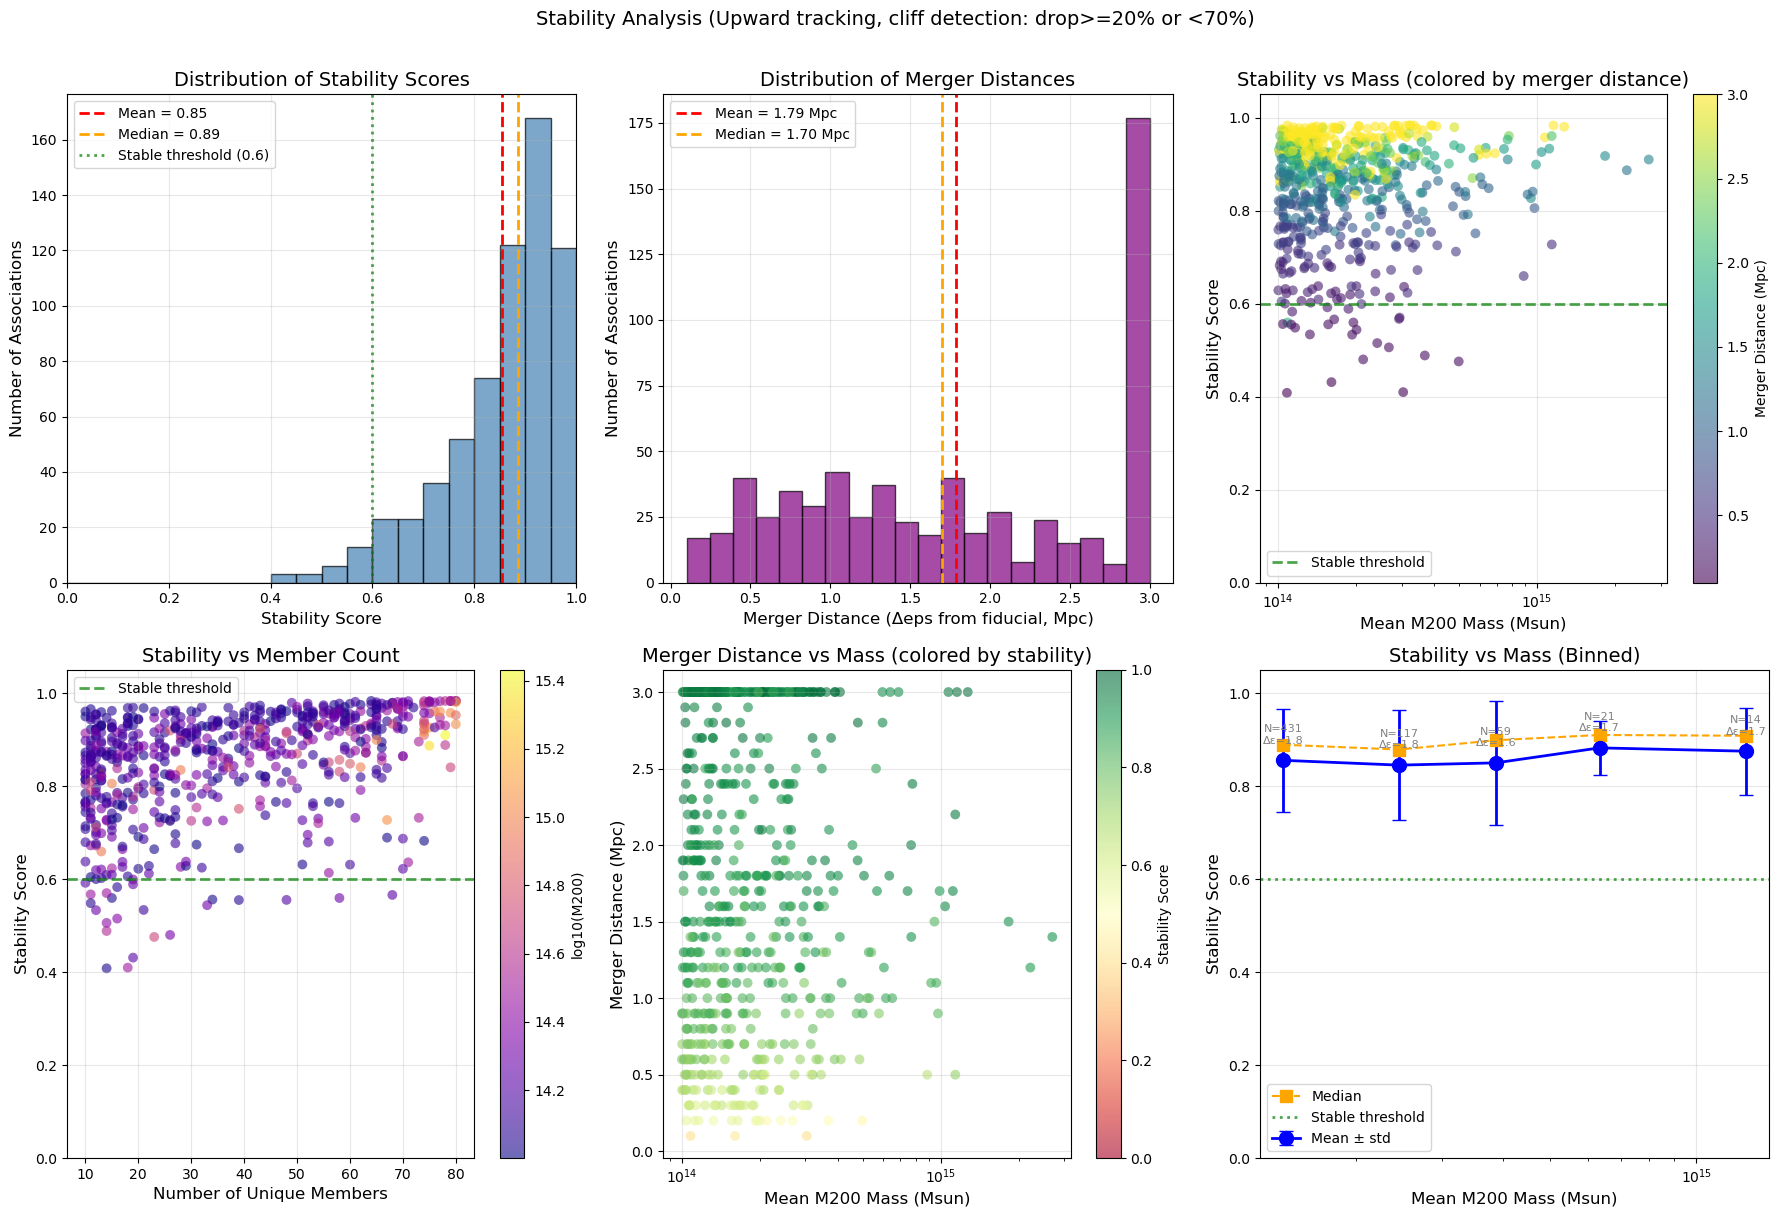


TOP 10 MOST STABLE ASSOCIATIONS
   ID  Mass (Msun)  N_members  Stability  Δeps_merger
-------------------------------------------------------
  131     1.16e+15         80      0.983         3.00
  159     3.35e+14         79      0.983         3.00
  166     3.24e+14         80      0.983         3.00
  194     3.92e+14         79      0.983         3.00
  200     3.22e+14         80      0.983         3.00
  449     1.08e+14         64      0.983         3.00
   78     3.90e+14         78      0.983         3.00
  295     2.80e+14         79      0.983         3.00
  103     1.76e+14         71      0.983         3.00
  272     3.12e+14         74      0.983         3.00

TOP 10 LEAST STABLE ASSOCIATIONS (excluding S=0)
   ID  Mass (Msun)  N_members  Stability  Δeps_merger
-------------------------------------------------------
 1179     1.33e+14         21      0.534         0.20
  738     1.93e+14         12      0.533         0.20
  872     2.41e+14         16      0.515         

In [35]:
# Visualize stability distribution and correlations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Stability histogram
ax1 = axes[0, 0]
bins = np.linspace(0, 1, 21)
ax1.hist(stabilities, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(np.mean(stabilities), color='red', linestyle='--', linewidth=2, 
            label=f'Mean = {np.mean(stabilities):.2f}')
ax1.axvline(np.median(stabilities), color='orange', linestyle='--', linewidth=2,
            label=f'Median = {np.median(stabilities):.2f}')
ax1.axvline(0.6, color='green', linestyle=':', linewidth=2, alpha=0.7,
            label='Stable threshold (0.6)')
ax1.set_xlabel('Stability Score', fontsize=12)
ax1.set_ylabel('Number of Associations', fontsize=12)
ax1.set_title('Distribution of Stability Scores', fontsize=14)
ax1.legend(fontsize=10)
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

# Plot 2: Merger distance histogram
ax2 = axes[0, 1]
valid_merger = ~np.isnan(merger_distances)
ax2.hist(merger_distances[valid_merger], bins=20, edgecolor='black', alpha=0.7, color='purple')
ax2.axvline(np.nanmean(merger_distances), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {np.nanmean(merger_distances):.2f} Mpc')
ax2.axvline(np.nanmedian(merger_distances), color='orange', linestyle='--', linewidth=2,
            label=f'Median = {np.nanmedian(merger_distances):.2f} Mpc')
ax2.set_xlabel('Merger Distance (Δeps from fiducial, Mpc)', fontsize=12)
ax2.set_ylabel('Number of Associations', fontsize=12)
ax2.set_title('Distribution of Merger Distances', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Stability vs Mass
ax3 = axes[0, 2]
scatter = ax3.scatter(masses, stabilities, c=merger_distances, cmap='viridis', 
                      alpha=0.6, s=50, edgecolors='none')
ax3.axhline(0.6, color='green', linestyle='--', linewidth=2, alpha=0.7,
            label='Stable threshold')
ax3.set_xlabel('Mean M200 Mass (Msun)', fontsize=12)
ax3.set_ylabel('Stability Score', fontsize=12)
ax3.set_title('Stability vs Mass (colored by merger distance)', fontsize=14)
ax3.set_xscale('log')
ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Merger Distance (Mpc)', fontsize=10)

# Plot 4: Stability vs N members
ax4 = axes[1, 0]
scatter2 = ax4.scatter(n_members_arr, stabilities, c=np.log10(masses), cmap='plasma',
                       alpha=0.6, s=50, edgecolors='none')
ax4.axhline(0.6, color='green', linestyle='--', linewidth=2, alpha=0.7,
            label='Stable threshold')
ax4.set_xlabel('Number of Unique Members', fontsize=12)
ax4.set_ylabel('Stability Score', fontsize=12)
ax4.set_title('Stability vs Member Count', fontsize=14)
ax4.set_ylim(0, 1.05)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax4)
cbar2.set_label('log10(M200)', fontsize=10)

# Plot 5: Merger distance vs Mass
ax5 = axes[1, 1]
scatter3 = ax5.scatter(masses[valid_merger], merger_distances[valid_merger], 
                       c=stabilities[valid_merger], cmap='RdYlGn',
                       alpha=0.6, s=50, edgecolors='none', vmin=0, vmax=1)
ax5.set_xlabel('Mean M200 Mass (Msun)', fontsize=12)
ax5.set_ylabel('Merger Distance (Mpc)', fontsize=12)
ax5.set_title('Merger Distance vs Mass (colored by stability)', fontsize=14)
ax5.set_xscale('log')
ax5.grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=ax5)
cbar3.set_label('Stability Score', fontsize=10)

# Plot 6: Stability vs Mass in bins
ax6 = axes[1, 2]
mass_bins = [1e14, 2e14, 3e14, 5e14, 8e14, 2e15]
mass_bin_centers = []
stability_means = []
stability_stds = []
stability_medians = []
merger_dist_means = []
n_per_bin = []

for i in range(len(mass_bins) - 1):
    mask = (masses >= mass_bins[i]) & (masses < mass_bins[i + 1])
    if np.sum(mask) >= 3:
        mass_bin_centers.append(np.sqrt(mass_bins[i] * mass_bins[i + 1]))
        stability_means.append(np.mean(stabilities[mask]))
        stability_stds.append(np.std(stabilities[mask]))
        stability_medians.append(np.median(stabilities[mask]))
        merger_dist_means.append(np.nanmean(merger_distances[mask]))
        n_per_bin.append(np.sum(mask))

mass_bin_centers = np.array(mass_bin_centers)
stability_means = np.array(stability_means)
stability_stds = np.array(stability_stds)
stability_medians = np.array(stability_medians)
merger_dist_means = np.array(merger_dist_means)

ax6.errorbar(mass_bin_centers, stability_means, yerr=stability_stds, 
             fmt='o-', markersize=10, linewidth=2, capsize=5, color='blue',
             label='Mean ± std')
ax6.plot(mass_bin_centers, stability_medians, 's--', markersize=8, 
         color='orange', label='Median')
ax6.axhline(0.6, color='green', linestyle=':', linewidth=2, alpha=0.7,
            label='Stable threshold')
ax6.set_xlabel('Mean M200 Mass (Msun)', fontsize=12)
ax6.set_ylabel('Stability Score', fontsize=12)
ax6.set_title('Stability vs Mass (Binned)', fontsize=14)
ax6.set_xscale('log')
ax6.set_ylim(0, 1.05)
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)

# Add N counts and merger distance to binned plot
for x, y, n, md in zip(mass_bin_centers, stability_means, n_per_bin, merger_dist_means):
    ax6.annotate(f'N={n}\nΔε={md:.1f}', (x, y), textcoords="offset points", 
                xytext=(0, 12), ha='center', fontsize=8, color='gray')

plt.suptitle(f'Stability Analysis (Upward tracking, cliff detection: drop>={STABILITY_DROP_THR*100:.0f}% or <{STABILITY_MIN_REC*100:.0f}%)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print most and least stable associations
print("\n" + "="*90)
print("TOP 10 MOST STABLE ASSOCIATIONS")
print("="*90)
sorted_by_stability = sorted(all_stabilities, key=lambda x: x['stability'], reverse=True)
print(f"{'ID':>5} {'Mass (Msun)':>12} {'N_members':>10} {'Stability':>10} {'Δeps_merger':>12}")
print("-"*55)
for s in sorted_by_stability[:10]:
    md = s['components'].get('merger_distance', np.nan)
    md_str = f"{md:.2f}" if not np.isnan(md) else "N/A"
    print(f"{s['cluster_id']:>5} {s['mass']:>12.2e} {s['n_members']:>10} {s['stability']:>10.3f} {md_str:>12}")

print("\n" + "="*90)
print("TOP 10 LEAST STABLE ASSOCIATIONS (excluding S=0)")
print("="*90)
nonzero = [s for s in sorted_by_stability if s['stability'] > 0]
print(f"{'ID':>5} {'Mass (Msun)':>12} {'N_members':>10} {'Stability':>10} {'Δeps_merger':>12}")
print("-"*55)
for s in nonzero[-10:]:
    md = s['components'].get('merger_distance', np.nan)
    md_str = f"{md:.2f}" if not np.isnan(md) else "N/A"
    print(f"{s['cluster_id']:>5} {s['mass']:>12.2e} {s['n_members']:>10} {s['stability']:>10.3f} {md_str:>12}")